In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.stats import linregress
from visualizations import lineplots_4x4
from processing import filter_region
from scipy.optimize import curve_fit
from scipy.stats import gaussian_kde

# load prediction arrays, create array objects

In [2]:
def load_arrs(arr_type: str, folder_path):
    if arr_type not in ['sum', 'mean', 'var', 'label']: raise ValueError ('---Insert "sum" or "mean" "var" or "label" as input---')
    return_arr = np.empty((110, 100, 7493)) if arr_type == 'sum' else np.empty((110, 7493))
    for arr_index in range(110):
        arr_temp = np.load(f'{folder_path}image{arr_index}/{arr_type}_arr_image{arr_index}.npy')
        return_arr[arr_index] = arr_temp
    return return_arr

In [3]:
folder_path_stochbin = 'predictions/8-27-2025/'
folder_path_sigma10 = 'predictions/sigma10'

In [4]:
stochbin_sum = load_arrs('sum', folder_path_stochbin)
stochbin_mean = load_arrs('mean', folder_path_stochbin)
stochbin_var = load_arrs('var', folder_path_stochbin)
stochbin_label = load_arrs('label', folder_path_stochbin)

In [5]:
# load for those in sigma10
"""
later need to make this generalize to different systems
"""
sigma10_sum = np.load(folder_path_sigma10 + "/sum_sigma10.npy")
sigma10_mean = np.load(folder_path_sigma10 + "/mean_sigma10.npy")
sigma10_var = np.load(folder_path_sigma10 + "/var_sigma10.npy")
sigma10_label = np.load(folder_path_sigma10 + "/labels_sigma10.npy")

# get mean and var arrays from V1
filtering done as well

get region 1 here

In [6]:
v1mean_stochbin = filter_region(1, stochbin_label, stochbin_mean)
v1var_stochbin = filter_region(1, stochbin_label, stochbin_var)

"""
NOTE USING LABELS FROM V1MEAN TO FILTER HERE, ASSUMING THIS IS FINE SINCE IT IS THE SAME NEURONS 
"""

v1mean_sigma10 = filter_region(1, stochbin_label, sigma10_mean)
v1var_sigma10 = filter_region(1, stochbin_label, sigma10_var)

In [7]:
# delete 9 grey images

v1mean_sigma10 = v1mean_sigma10[9:, ...]
v1var_sigma10 = v1var_sigma10[9:,...]
v1mean_stochbin = v1mean_stochbin[9:,...]
v1var_stochbin = v1var_stochbin[9:,...]

# remove values

after 11/20 meeting removing anything >100

In [8]:
mask_gaus = v1mean_sigma10 <= 100
mask_bernoulli = v1mean_stochbin <= 100

In [9]:
v1mean_sigma10[~mask_gaus] = np.nan
v1var_sigma10[~mask_gaus] = np.nan
v1mean_stochbin[~mask_bernoulli] = np.nan
v1var_stochbin[~mask_bernoulli] = np.nan

# get indices to sort

## *without removed values*

In [10]:
stochbin_med = np.nanmedian(v1mean_stochbin, axis = 0)
sigma10_med = np.nanmedian(v1mean_sigma10, axis = 0)

In [11]:
stochbin_sort_indices = np.argsort(stochbin_med)[::-1]
sigma10_sort_indices = np.argsort(sigma10_med)[::-1]

In [12]:
# use this OTHERWISE
stochbin_meanv1 = v1mean_stochbin[..., stochbin_sort_indices]
stochbin_varv1 = v1var_stochbin[..., stochbin_sort_indices]

sigma10_meanv1 = v1mean_sigma10[..., sigma10_sort_indices]
sigma10_varv1 = v1var_sigma10[..., sigma10_sort_indices]

# ax**b function in log log space
*scatter plot*

In [13]:
def smooth_func(a, x, b): # used for regression in lineplots_4x4

    return a * (x ** b)

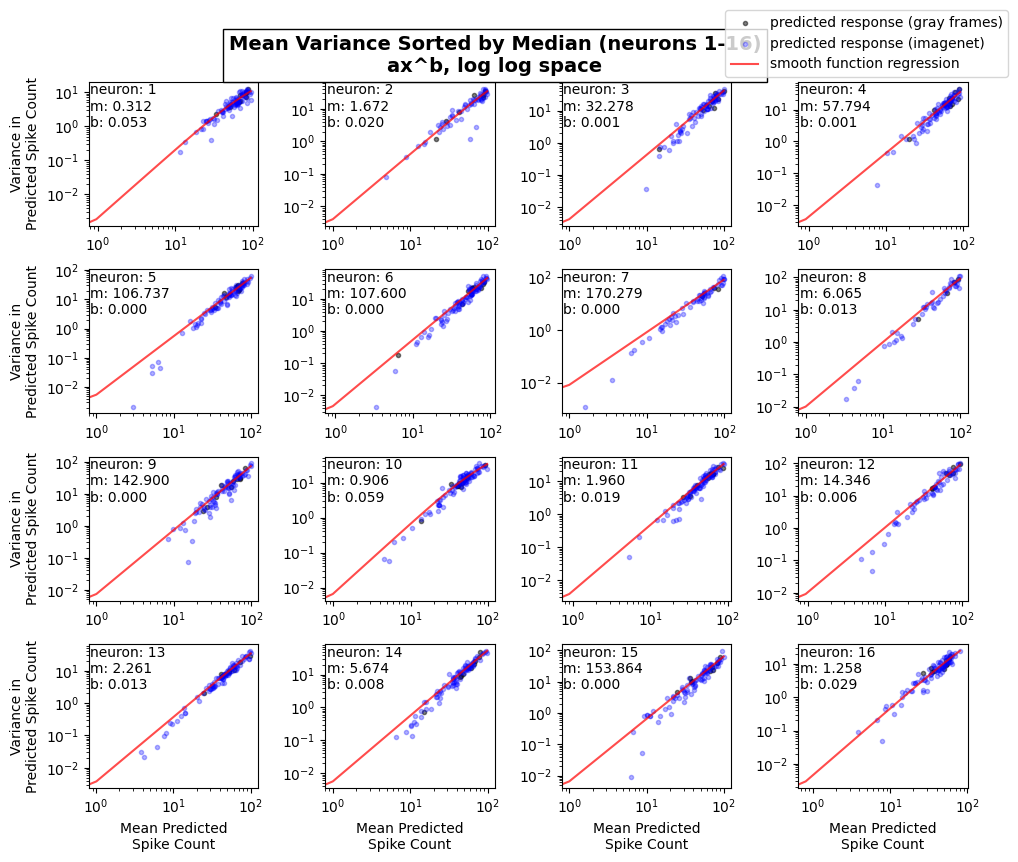

In [14]:
lineplots_4x4("Mean Variance Sorted by Median (neurons 1-16)\nax^b, log log space", stochbin_meanv1, stochbin_varv1, neurons = [i for i in range(16)], savefig = False, logspace = True)

# regression
log(y) = a + blog(x)

In [15]:
mean_masked, var_masked = stochbin_meanv1, stochbin_varv1
main_title = "Mean Variance Scatter Plot\nBernoulli (neurons 1-16)"

In [16]:
def scatter_plots(main_title, mean_masked, var_masked, neurons = [i for i in range(16)], loglog_space = False, savefig = False):
    """
    Scatter plot of mean and variance spike counts with option to plot in log log space. If figure saved will save to same directory as script.
    """
    def smooth_func(x, a, b):

        return a * (x**b)
    
    fig, axes = plt.subplots(4, 4, figsize=(10, 8), sharex=False, sharey=False)
    for id, neuron in enumerate(neurons):
        i, j = divmod(id, 4)
        ax = axes[i, j]
        x = mean_masked[..., neuron]
        y = var_masked[..., neuron]
        
    # Mask valid (finite) values
        mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
        x = x[mask]
        y = y[mask]
    
        if loglog_space:
            """ENSURE REGRESSION DONE CORRECTLY"""
            logx = np.log(x)
            logy = np.log(y)
            b, a, r_value, p_value, std_err = linregress(logx, logy)
            r_squared = r_value**2

            x_fit = np.linspace(x.min(), x.max(), mean_masked.shape[0]) 
            y_fit = np.exp(a) * x_fit**b
            max_exp = np.max(x_fit) 
            ax.loglog(x, y, '.', label = 'original mean and var points')
            ax.loglog(x_fit, y_fit, '-', color = 'r', label = 'regression')
            ax.axline((0, 0), (max_exp, max_exp), color='black', linestyle='--', label='Identity Line (y=x)')
        else:
            params, covariance = curve_fit(smooth_func, x, y, maxfev = 1_000_000_000, p0 = [1, .001])
            a, b = params[0], params[1]
            x_pred = np.linspace(0, max(x), mean_masked.shape[0]) # ensure we use same number of points as there are images
            y_pred = smooth_func(x_pred, params[0], params[1]) 
            ax.scatter(x, y, marker = '.', label = 'original mean and var points')
            ax.plot(x_pred, y_pred, color = 'r', label = 'smooth function regression', alpha = 0.7)
            max_exp = np.max(x_pred)
            ax.axline((0, 0), (max_exp, max_exp), color='black', linestyle='--', label='Identity Line (y=x)')


        ax.text(0.01, 0.99, f'neuron: {neuron+1}\nb: {b:.3f}\na: {a:.3f}', verticalalignment = 'top', horizontalalignment = 'left', 
            transform = ax.transAxes)

        if i == 3: ax.set_xlabel("mean spike count")
        if j == 0: ax.set_ylabel("variance in spike count")
    fig.text(0.5, 1.04, main_title, ha='center', va='top', fontsize=14,  bbox=dict(facecolor='white'))

    if savefig:
        import time
        current_time = time.localtime()
        formatted_time = time.strftime("%Y-%m-%d", current_time)
        plt.savefig(f"scatterplot({formatted_time}).pdf")
    else:
        plt.tight_layout()
        plt.show()
    return

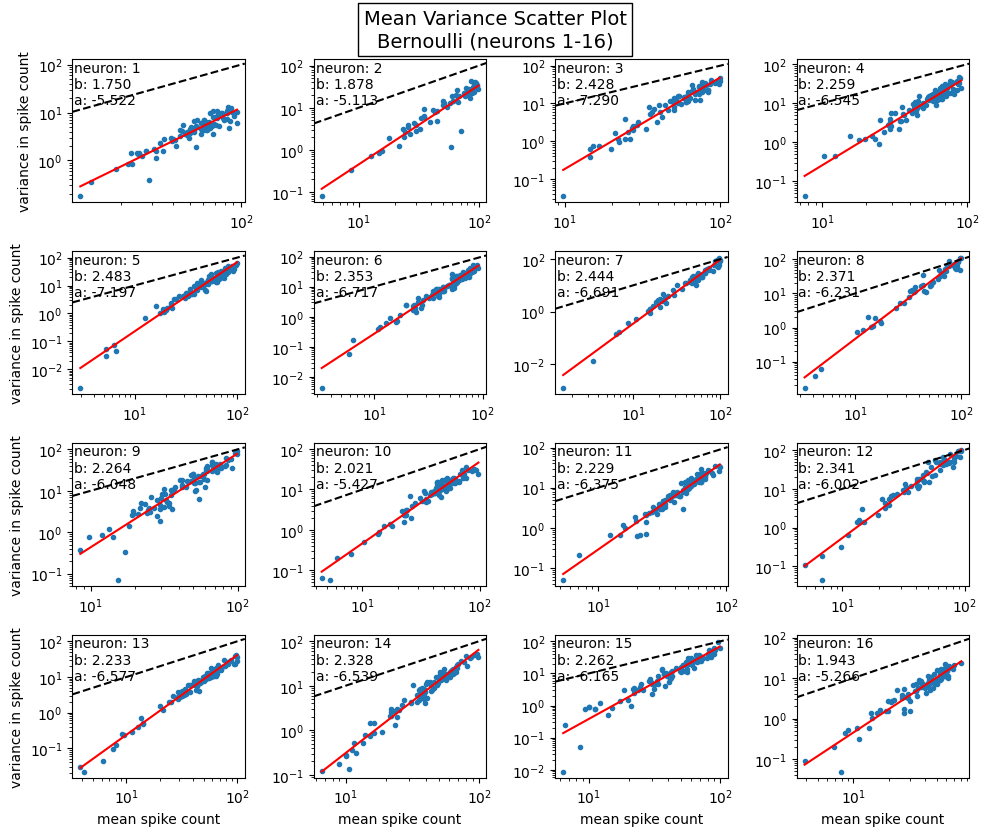

In [17]:
scatter_plots(main_title, stochbin_meanv1, stochbin_varv1, loglog_space = True)

Note our points fall lower than identity line in real neurons, intercept is lower as well.

In [18]:
mean_masked, var_masked = sigma10_meanv1, sigma10_varv1
main_title = "Mean Variance Scatter Plot\nDynamic Gaussian Noise with Sigma=10 (neurons 1-16)"

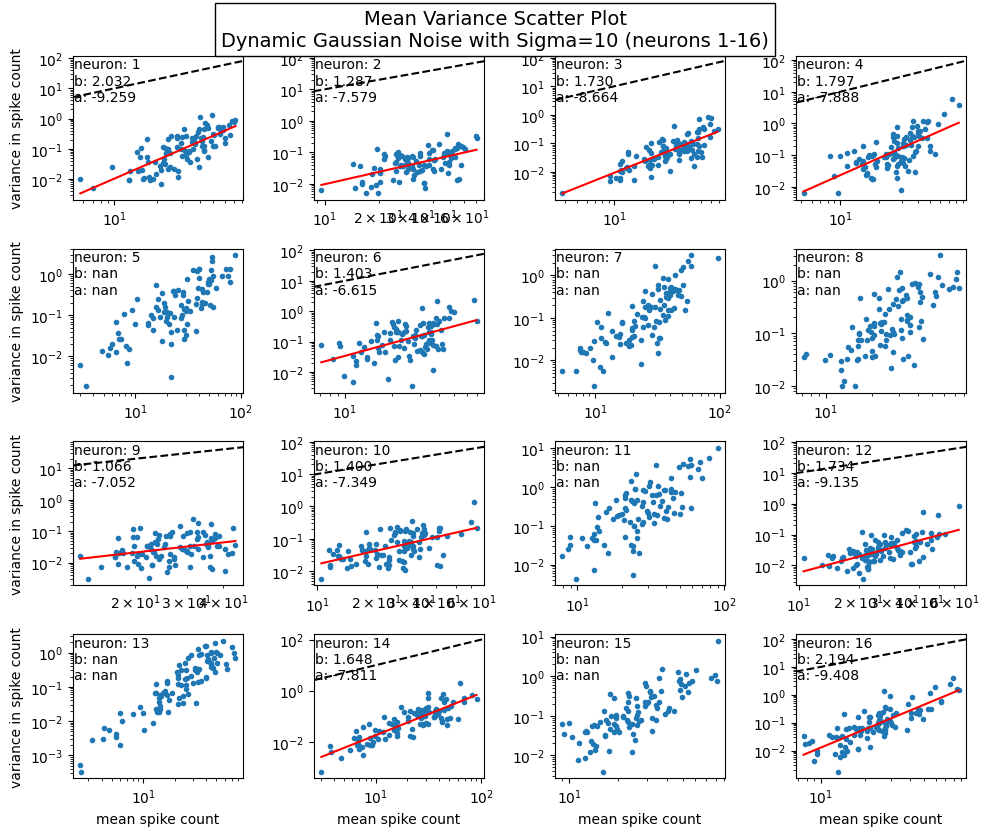

In [19]:
fig, axes = plt.subplots(4, 4, figsize=(10, 8), sharex=False, sharey=False)
neurons = [i for i in range(16)]
for id, neuron in enumerate(neurons):
    i, j = divmod(id, 4)
    ax = axes[i, j]
    x = mean_masked[..., neuron]
    y = var_masked[..., neuron]
    logx = np.log(x)
    logy = np.log(y)

    b, a, r_value, p_value, std_err = linregress(logx, logy)
    r_squared = r_value**2

    x_fit = np.linspace(x.min(), x.max(), 101)
    y_fit = np.exp(a) * x_fit**b

    ax.loglog(x, y, '.', label = 'original mean and var points')
    ax.loglog(x_fit, y_fit, '-', color = 'r', label = 'regression')
    max_exp = np.max(x_fit)
    ax.axline((0, 0), (max_exp, max_exp), color='black', linestyle='--', label='Identity Line (y=x)')
    ax.text(0.01, 0.99, f'neuron: {neuron+1}\nb: {b:.3f}\na: {a:.3f}', verticalalignment = 'top', horizontalalignment = 'left', 
        transform = ax.transAxes)

    if i == 3: ax.set_xlabel("mean spike count")
    if j == 0: ax.set_ylabel("variance in spike count")
fig.text(0.5, 1.04, main_title, ha='center', va='top', fontsize=14,  bbox=dict(facecolor='white'))
plt.tight_layout()
plt.show()

In [20]:
mean_masked, var_masked = stochbin_meanv1, stochbin_varv1
main_title ="variance = a*mean^b\\Bernoulli (neurons 1-16)"

# pre allocate statistics 
stochbin_medians = []
stochbin_alist = []
stochbin_blist = []
stochbin_rsqlist = []

neurons = [i for i in range(16)]
for neuron in range(mean_masked.shape[1]):
    x = mean_masked[..., neuron]
    y = var_masked[..., neuron]
    med = np.median(x)
    logx = np.log(x)
    logy = np.log(y)

    b, a, r_value, p_value, std_err = linregress(logx, logy) # should fit regression on log model correct?
    r_squared = r_value**2

    stochbin_medians.append(med)
    stochbin_alist.append(a)
    stochbin_blist.append(b)
    stochbin_rsqlist.append(r_squared)
stochbin_alist = np.exp(stochbin_alist)


#---now do for sigma=10 dynamic gaussian noise---
sigma10_medians = []
sigma10_alist = []
sigma10_blist = []
sigma10_rsqlist = []

mean_masked, var_masked = sigma10_meanv1, sigma10_varv1
neurons = [i for i in range(16)]
for neuron in range(mean_masked.shape[1]):
    x = mean_masked[..., neuron]
    y = var_masked[..., neuron]
    med = np.median(x)
    logx = np.log(x)
    logy = np.log(y)

    b, a, r_value, p_value, std_err = linregress(logx, logy) # should fit regression on log model correct?
    r_squared = r_value**2

    sigma10_medians.append(med)
    sigma10_alist.append(a)
    sigma10_blist.append(b)
    sigma10_rsqlist.append(r_squared)
sigma10_alist = np.exp(sigma10_alist)


# a,b, r^2 versus median

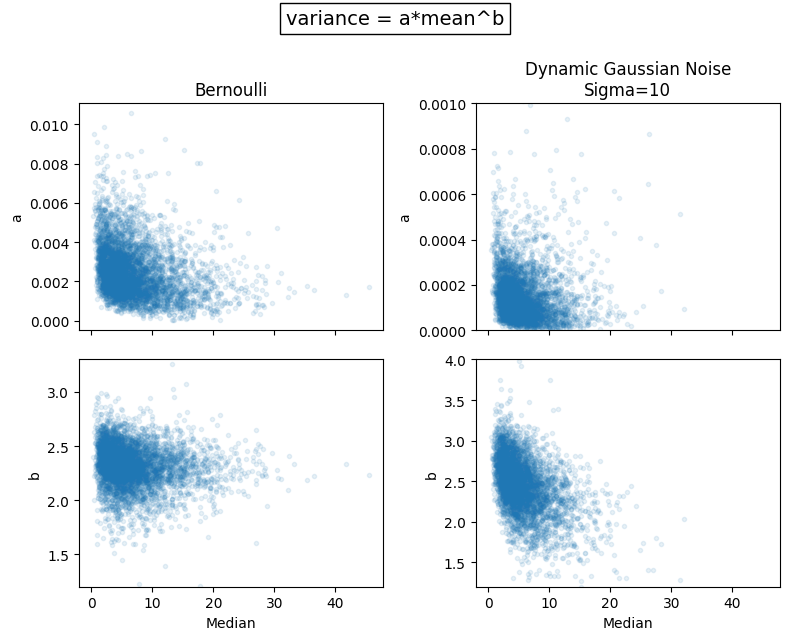

In [21]:
"""
do 2 sets of plots
1) 2x2 for equation parameters (a and b) by different type of noise 
2) r_squared for each (just 2 scatter plots side by side)
"""

fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharex=True, sharey=False)

axes[0,0].scatter(stochbin_medians, stochbin_alist, marker = ".", alpha = 0.1)
axes[0,0].set_ylabel("a")
#axes[0,0].set_ylim(0, 0.001)
axes[0,0].set_title("Bernoulli")

axes[1,0].scatter(stochbin_medians, stochbin_blist, marker = ".", alpha = 0.1)
axes[1,0].set_ylabel("b")
axes[1,0].set_ylim(1.2, 3.3)
axes[1,0].set_xlabel("Median")

axes[0,1].scatter(sigma10_medians, sigma10_alist, marker = ".", alpha = 0.1)
axes[0,1].set_ylabel("a")
axes[0,1].set_ylim(0, 0.001) 
axes[0,1].set_title("Dynamic Gaussian Noise\nSigma=10")

axes[1,1].scatter(sigma10_medians, sigma10_blist, marker = ".", alpha = 0.1)
axes[1,1].set_ylabel("b")
axes[1,1].set_ylim(1.2, 4)
axes[1,1].set_xlabel("Median")


fig.text(0.5, 1.06, "variance = a*mean^b", ha='center', va='top', fontsize=14,  bbox=dict(facecolor='white'))
plt.tight_layout()
plt.show()
# if want to save plots as pdf
#plt.savefig("scatterplots.pdf")
#plt.close()

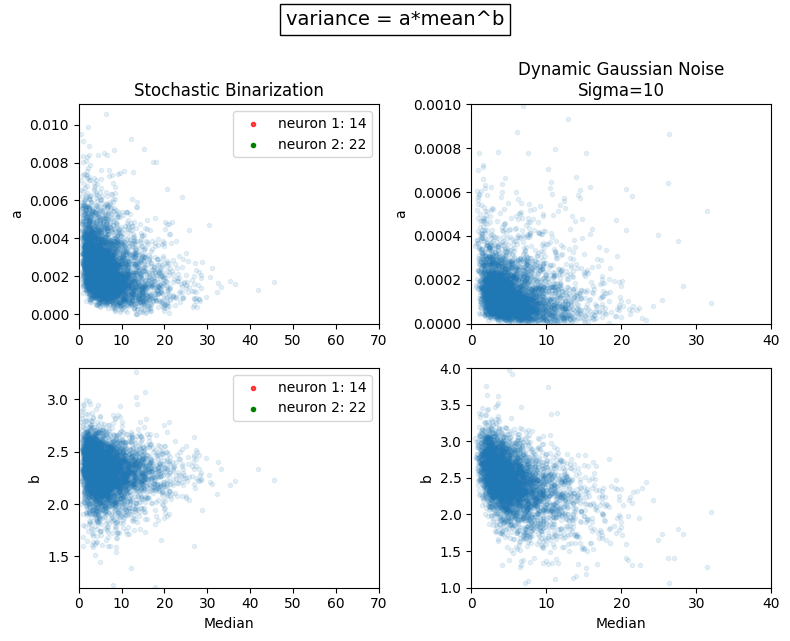

median: nan; b: nan; a: nan
median: nan; b: nan; a: nan


In [22]:
"""
single out neuron i and show a against b
"""
neuron1 = 13
neuron2 = 21

fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharey=False)

axes[0,0].scatter(stochbin_medians, stochbin_alist, marker = ".", alpha = 0.1)
axes[0,0].scatter(stochbin_medians[neuron1], stochbin_alist[neuron1], marker = ".", 
                  color = "red", label = f"neuron 1: {neuron1+1}", alpha=0.7)
axes[0,0].scatter(stochbin_medians[neuron2], stochbin_alist[neuron2], marker = ".", color = "g", label = f"neuron 2: {neuron2+1}")
axes[0,0].set_ylabel("a")
axes[0,0].set_title("Stochastic Binarization")
axes[0,0].legend()
axes[0,0].set_xlim(0, 70)

axes[1,0].scatter(stochbin_medians, stochbin_blist, marker = ".", alpha = 0.1)
axes[1,0].scatter(stochbin_medians[neuron1], stochbin_blist[neuron1], marker = ".", 
                  color = "r", label = f"neuron 1: {neuron1+1}", alpha=0.7)
axes[1,0].scatter(stochbin_medians[neuron2], stochbin_blist[neuron2], marker = ".", color = "g", label = f"neuron 2: {neuron2+1}")
axes[1,0].set_ylabel("b")
axes[1,0].set_ylim(1.2, 3.3)
axes[1,0].set_xlabel("Median")
axes[1,0].legend()
axes[1,0].set_xlim(0, 70)

axes[0,1].scatter(sigma10_medians, sigma10_alist, marker = ".", alpha = 0.1)
axes[0,1].set_ylabel("a")
axes[0,1].set_ylim(0, 0.001) 
axes[0,1].set_title("Dynamic Gaussian Noise\nSigma=10")
axes[0,1].set_xlim(0, 40)

axes[1,1].scatter(sigma10_medians, sigma10_blist, marker = ".", alpha = 0.1)
axes[1,1].set_ylabel("b")
axes[1,1].set_ylim(1, 4)
axes[1,1].set_xlabel("Median")
axes[1,1].set_xlim(0, 40)

fig.text(0.5, 1.06, "variance = a*mean^b", ha='center', va='top', fontsize=14,  bbox=dict(facecolor='white'))
plt.tight_layout()
plt.show()
# if want to save plots as pdf
#plt.savefig("scatterplots.pdf")
#plt.close()

print(f"median: {stochbin_medians[neuron1]:.4f}; b: {stochbin_blist[neuron1]:.4f}; a: {stochbin_alist[neuron1]:.4f}")
print(f"median: {stochbin_medians[neuron2]:.4f}; b: {stochbin_blist[neuron2]:.4f}; a: {stochbin_alist[neuron2]:.4f}")

a1 = stochbin_alist[neuron1]
a2 = stochbin_alist[neuron2]

In [23]:
possible_neurons = np.where((np.array(stochbin_alist) > 0.006) & (np.array(stochbin_medians) > 45))

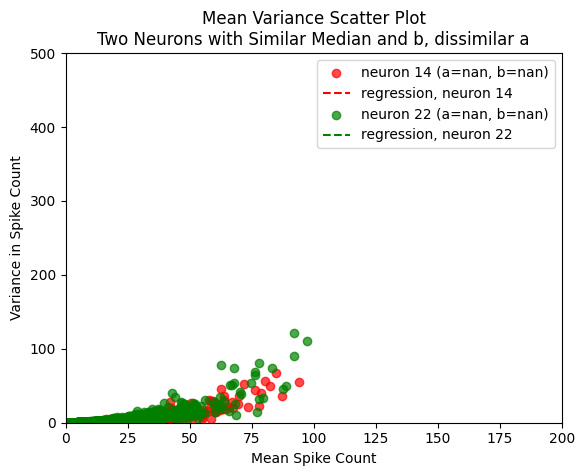

In [24]:
plt.scatter(stochbin_meanv1[neuron1], stochbin_varv1[neuron1], color = "r", 
            label = f"neuron {neuron1+1} (a={stochbin_alist[neuron1]:.3f}, b={stochbin_blist[neuron1]:.2f})", alpha = 0.7)
x = np.sort(stochbin_meanv1[neuron1])
y = stochbin_alist[neuron1] * x**stochbin_blist[neuron1]
plt.plot(x, y, label = f"regression, neuron {neuron1+1}", linestyle = "--", color = "r")

plt.scatter(stochbin_meanv1[neuron2], stochbin_varv1[neuron2], color = "g", 
            label = f"neuron {neuron2+1} (a={stochbin_alist[neuron2]:.3f}, b={stochbin_blist[neuron2]:.2f})", alpha = 0.7)
x = np.sort(stochbin_meanv1[neuron2])
y = stochbin_alist[neuron2] * x**stochbin_blist[neuron2]
plt.plot(x, y, label = f"regression, neuron {neuron2+1}", linestyle = "--", color = "g")

plt.legend()
plt.xlabel("Mean Spike Count")
plt.ylabel("Variance in Spike Count")
plt.title("Mean Variance Scatter Plot\nTwo Neurons with Similar Median and b, dissimilar a")
plt.ylim(0, 500)
plt.xlim(0, 200)
plt.show()

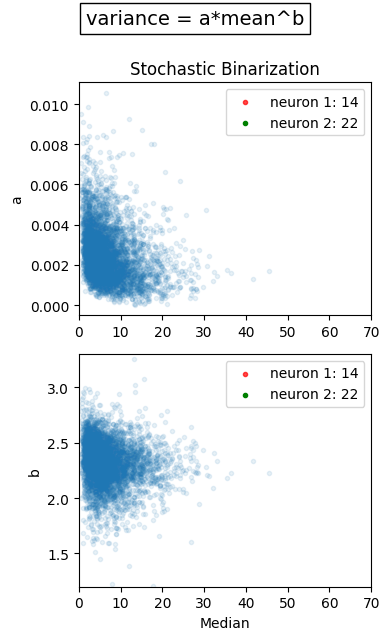

median: nan; b: nan; a: nan
median: nan; b: nan; a: nan


In [25]:
"""
single out neuron i and show a against b
"""
neuron1 = 13
neuron2 = 21

fig, axes = plt.subplots(2, 1, figsize=(4, 6), sharey=False)

axes[0].scatter(stochbin_medians, stochbin_alist, marker = ".", alpha = 0.1)
axes[0].scatter(stochbin_medians[neuron1], stochbin_alist[neuron1], marker = ".", 
                  color = "red", label = f"neuron 1: {neuron1+1}", alpha=0.7)
axes[0].scatter(stochbin_medians[neuron2], stochbin_alist[neuron2], marker = ".", color = "g", label = f"neuron 2: {neuron2+1}")
axes[0].set_ylabel("a")
axes[0].set_title("Stochastic Binarization")
axes[0].legend()
axes[0].set_xlim(0, 70)

axes[1].scatter(stochbin_medians, stochbin_blist, marker = ".", alpha = 0.1)
axes[1].scatter(stochbin_medians[neuron1], stochbin_blist[neuron1], marker = ".", 
                  color = "r", label = f"neuron 1: {neuron1+1}", alpha=0.7)
axes[1].scatter(stochbin_medians[neuron2], stochbin_blist[neuron2], marker = ".", color = "g", label = f"neuron 2: {neuron2+1}")
axes[1].set_ylabel("b")
axes[1].set_ylim(1.2, 3.3)
axes[1].set_xlabel("Median")
axes[1].legend()
axes[1].set_xlim(0, 70)

fig.text(0.5, 1.06, "variance = a*mean^b", ha='center', va='top', fontsize=14,  bbox=dict(facecolor='white'))
plt.tight_layout()
plt.show()
# if want to save plots as pdf
#plt.savefig("scatterplots.pdf")
#plt.close()

print(f"median: {stochbin_medians[neuron1]:.4f}; b: {stochbin_blist[neuron1]:.4f}; a: {stochbin_alist[neuron1]:.4f}")
print(f"median: {stochbin_medians[neuron2]:.4f}; b: {stochbin_blist[neuron2]:.4f}; a: {stochbin_alist[neuron2]:.4f}")

a1 = stochbin_alist[neuron1]
a2 = stochbin_alist[neuron2]

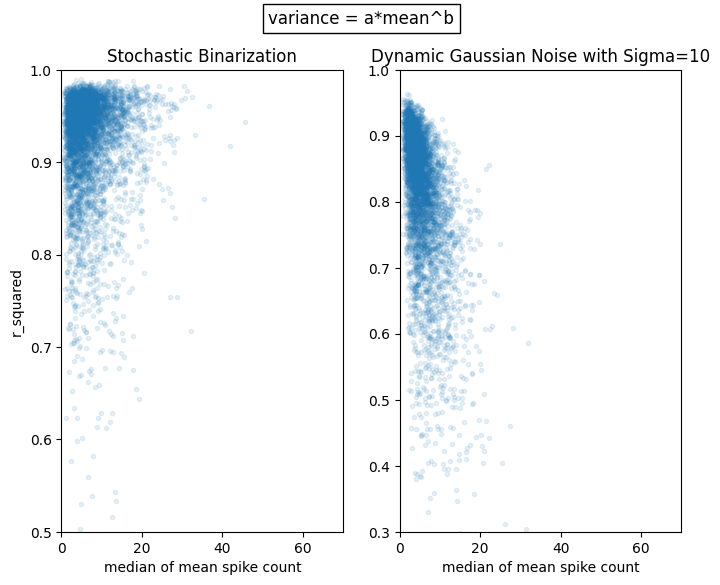

In [26]:
plt.figure(figsize = (8, 6))
plt.subplot(121)
plt.ylabel("r_squared")
plt.scatter(stochbin_medians, stochbin_rsqlist, marker = ".", alpha = 0.1)
plt.ylim(0.5, 1)
plt.xlim(0, 70)
plt.xlabel("median of mean spike count")
plt.title("Stochastic Binarization")

plt.subplot(122)
plt.title("Dynamic Gaussian Noise with Sigma=10")
plt.scatter(sigma10_medians, sigma10_rsqlist, marker = ".", alpha = 0.1)
plt.ylim(0.3, 1)
plt.xlim(0, 70)
plt.xlabel("median of mean spike count")

plt.suptitle("variance = a*mean^b", bbox=dict(facecolor='white'))
plt.show()

# histograms a, b, r^2

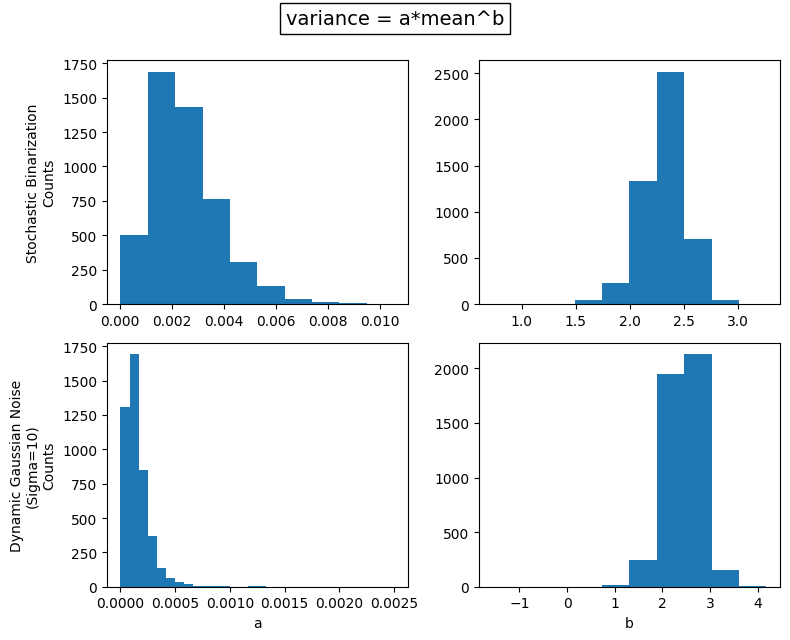

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

axes[0,0].hist(stochbin_alist)
axes[0,0].set_ylabel("Stochastic Binarization\nCounts")

axes[0,1].hist(stochbin_blist)

axes[1,0].hist(sigma10_alist, range = (0, 0.0025), bins = 30)
axes[1,0].set_xlabel("a")
axes[1,0].set_ylabel("Dynamic Gaussian Noise\n(Sigma=10)\nCounts")

axes[1,1].hist(sigma10_blist)
axes[1,1].set_xlabel("b")

fig.text(0.5, 1.06, "variance = a*mean^b", ha='center', va='top', fontsize=14,  bbox=dict(facecolor='white'))
plt.tight_layout()
plt.show()

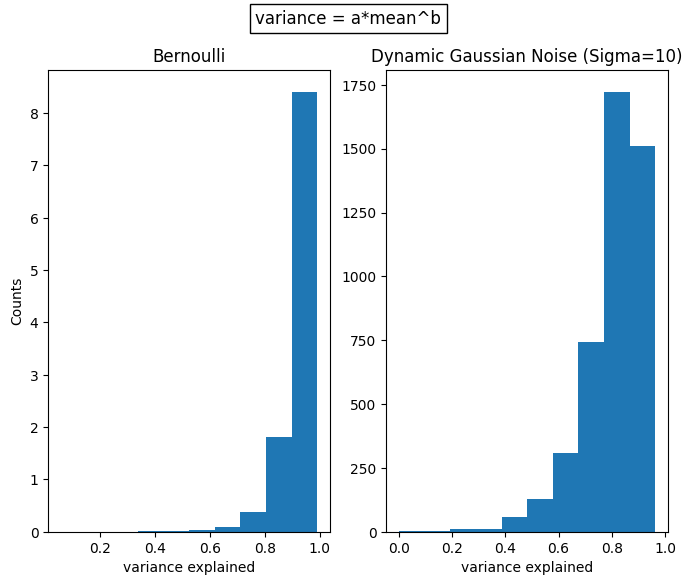

In [28]:
plt.figure(figsize = (8, 6))
plt.subplot(121)
plt.hist(stochbin_rsqlist, density =True)
plt.xlabel("variance explained")
plt.ylabel("Counts")
plt.title("Bernoulli")

plt.subplot(122)
plt.title("Dynamic Gaussian Noise (Sigma=10)")
plt.hist(sigma10_rsqlist)
plt.xlabel("variance explained")

plt.suptitle("variance = a*mean^b", bbox=dict(facecolor='white'))
plt.show()

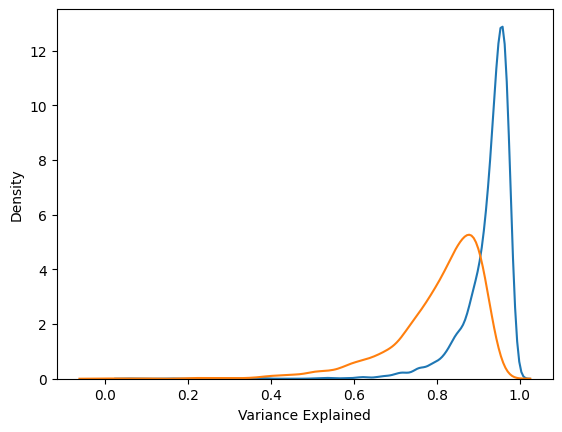

In [29]:
import seaborn as sns
sns.kdeplot(stochbin_rsqlist, label = "stochbin")
sns.kdeplot(sigma10_rsqlist, color = "tab:orange", label = "sigma10")
plt.xlabel("Variance Explained")
plt.show()

## ksdensity

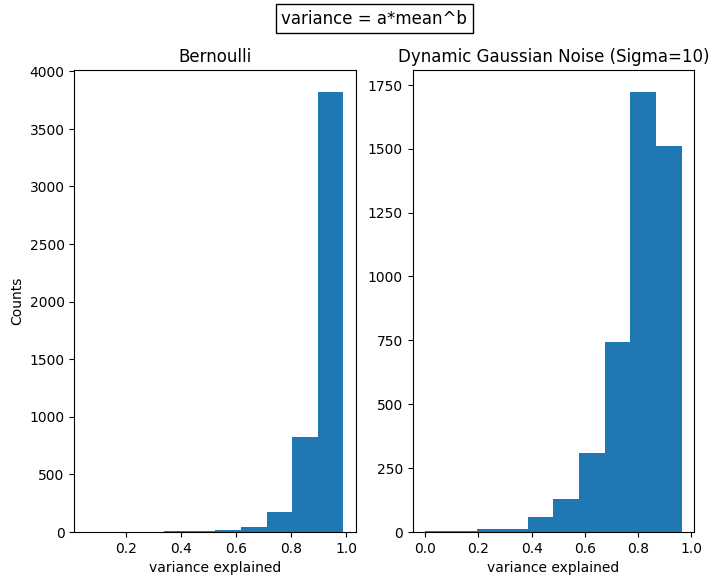

In [30]:
plt.figure(figsize = (8, 6))
plt.subplot(121)
plt.hist(stochbin_rsqlist)
plt.xlabel("variance explained")
plt.ylabel("Counts")
plt.title("Bernoulli")

plt.subplot(122)
plt.title("Dynamic Gaussian Noise (Sigma=10)")
plt.hist(sigma10_rsqlist)
plt.xlabel("variance explained")

plt.suptitle("variance = a*mean^b", bbox=dict(facecolor='white'))
plt.show()

# all neurons mean var scatter

In [31]:
x = stochbin_mean.flatten()
y = stochbin_var.flatten()

logx = np.log(x)
logy = np.log(y)

b, a, r_value, p_value, std_err = linregress(logx, logy)
r_squared = r_value**2

x_fit = np.linspace(x.min(), x.max(), 101)
y_fit = np.exp(a) * x_fit**b
max_exp = max(x_fit)

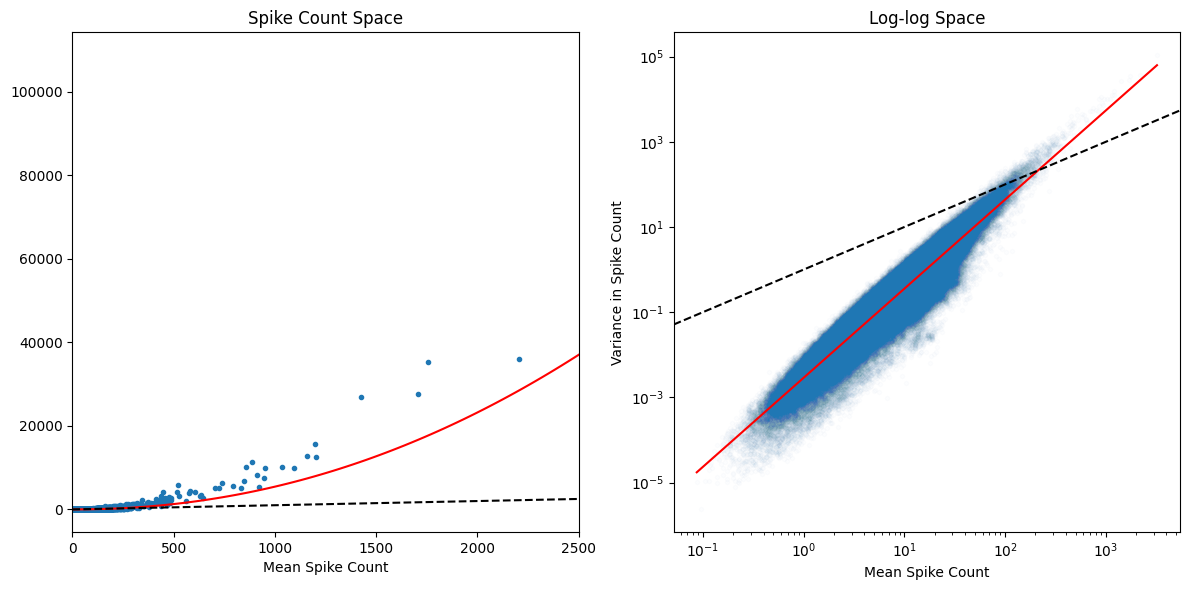

In [32]:
plt.figure(figsize = (12,6))
plt.subplot(121)
plt.scatter(x, y, marker = '.', label = 'original mean and var points')
plt.plot(x_fit, y_fit, color = 'r', label = 'regression')
plt.axline((0, 0), (max_exp, max_exp), color='black', linestyle='--', label='Identity Line (y=x)')
plt.title("Spike Count Space")
plt.xlabel("Mean Spike Count")
plt.xlim(0, 2500)

plt.subplot(122)
plt.loglog(x, y, '.', label = 'original mean and var points', alpha = 0.01)
plt.loglog(x_fit, y_fit, '-', color = 'r', label = 'regression')
plt.axline((0, 0), (max_exp, max_exp), color='black', linestyle='--', label='Identity Line (y=x)')
plt.title("Log-log Space")
plt.xlabel("Mean Spike Count")
plt.ylabel("Variance in Spike Count")
plt.tight_layout()

plt.show()

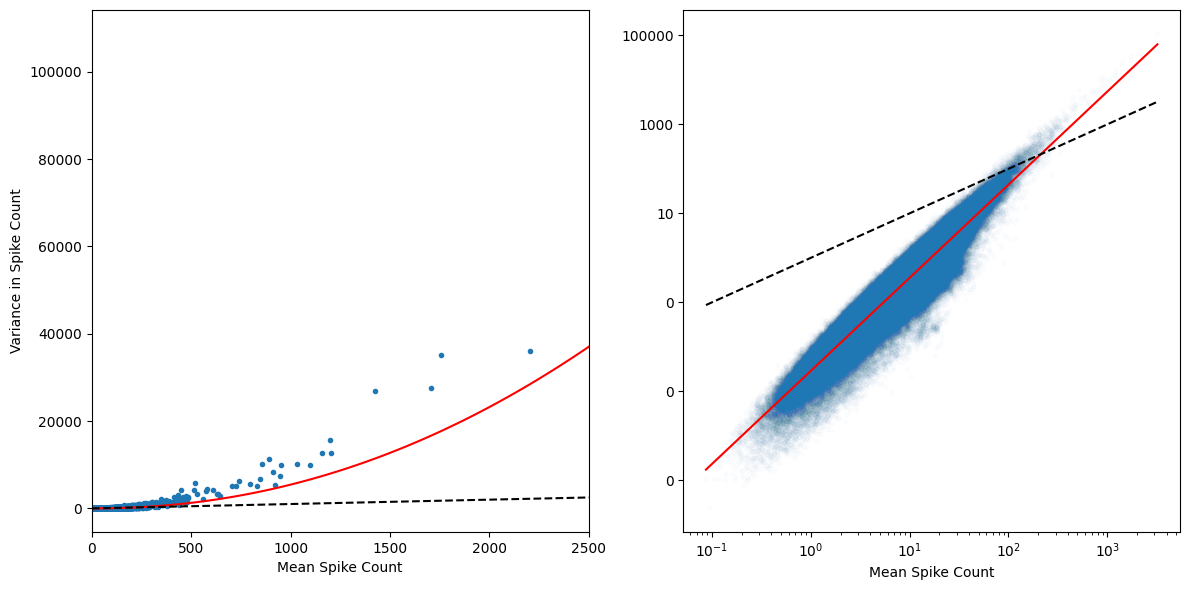

In [33]:
# ...existing code...
import matplotlib.ticker as ticker

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# left: linear
ax = axes[0]
ax.scatter(x, y, marker='.', label='original mean and var points')
ax.plot(x_fit, y_fit, color='r', label='regression')
ax.plot(x_fit, x_fit, '--', color='black', label='Identity Line (y=x)')   # identity line
ax.set_xlabel("Mean Spike Count")
ax.set_xlim(0, 2500)
ax.set_ylabel("Variance in Spike Count")


# formatter: no decimals
fmt = ticker.FuncFormatter(lambda v, pos: f"{v:.0f}")
ax.yaxis.set_major_formatter(fmt)

# right: log-log
ax2 = axes[1]
ax2.loglog(x, y, '.', alpha=0.01, label='original mean and var points')
ax2.loglog(x_fit, y_fit, '-', color='r', label='regression')
ax2.loglog(x_fit, x_fit, '--', color='black', label='Identity Line (y=x)')
ax2.set_xlabel("Mean Spike Count")
ax2.yaxis.set_major_formatter(fmt)   # apply same numeric format on log axis

plt.tight_layout()
plt.show()
# ...existing code...

# variance explained 

In [34]:

# --- Pooled (single) regression across all neurons for stochbin ---
# Fit a single log-log regression to all points (pooled over neurons),
# then compute R^2 for that global fit on each neuron separately.
# flatten across images and neurons for pooled fit (stochbin)
x_all = stochbin_mean.flatten()
y_all = stochbin_var.flatten()
# mask positive values to avoid log issues
mask_all = (x_all > 0) & (y_all > 0) & (~np.isnan(x_all)) & (~np.isnan(y_all))
x_all = x_all[mask_all]
y_all = y_all[mask_all]
logx_all = np.log(x_all)
logy_all = np.log(y_all)
# global fit on pooled data (stochbin)
b_global, a_global, r_val, p_val, std_err = linregress(logx_all, logy_all)
a_global_exp = np.exp(a_global)
print(f'Global pooled fit (stochbin): a = {a_global_exp:.4g}, b = {b_global:.4f}, R2 (pooled) = {r_val**2:.4f}')
# compute per-neuron R^2 using the global parameters (stochbin)
r2_global_per_neuron = []
n_neurons = stochbin_meanv1.shape[-1] if stochbin_meanv1.ndim>1 else stochbin_meanv1.shape[0]
for neuron in range(n_neurons):
    x_n = stochbin_meanv1[..., neuron].astype(float)
    y_n = stochbin_varv1[..., neuron].astype(float)
    mask = (x_n > 0) & (y_n > 0) & (~np.isnan(x_n)) & (~np.isnan(y_n))
    if mask.sum() < 2:
        r2_global_per_neuron.append(np.nan)
        continue
    # predicted in log space using a_global and b_global: log(yhat) = a + b log(x)
    logx_n = np.log(x_n[mask])
    logy_n = np.log(y_n[mask])
    logyhat = a_global + b_global * logx_n
    # compute R^2 on log-space (explained variance of log y)
    ss_res = np.sum((logy_n - logyhat)**2)
    ss_tot = np.sum((logy_n - np.mean(logy_n))**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
    r2_global_per_neuron.append(r2)
r2_global_per_neuron = np.array(r2_global_per_neuron)

# --- Pooled (single) regression across all neurons for sigma10 ---
# flatten across images and neurons for pooled fit (sigma10)
x_all_s = sigma10_mean.flatten()
y_all_s = sigma10_var.flatten()
mask_all_s = (x_all_s > 0) & (y_all_s > 0) & (~np.isnan(x_all_s)) & (~np.isnan(y_all_s))
x_all_s = x_all_s[mask_all_s]
y_all_s = y_all_s[mask_all_s]
logx_all_s = np.log(x_all_s)
logy_all_s = np.log(y_all_s)
# global fit on pooled data (sigma10)
b_global_s, a_global_s, r_val_s, p_val_s, std_err_s = linregress(logx_all_s, logy_all_s)
a_global_exp_s = np.exp(a_global_s)
print(f'Global pooled fit (sigma10): a = {a_global_exp_s:.4g}, b = {b_global_s:.4f}, R2 (pooled) = {r_val_s**2:.4f}')
# compute per-neuron R^2 using the global parameters (sigma10)
r2_global_per_neuron_sigma10 = []
n_neurons_s = sigma10_meanv1.shape[-1] if sigma10_meanv1.ndim>1 else sigma10_meanv1.shape[0]
for neuron in range(n_neurons_s):
    x_n = sigma10_meanv1[..., neuron].astype(float)
    y_n = sigma10_varv1[..., neuron].astype(float)
    mask = (x_n > 0) & (y_n > 0) & (~np.isnan(x_n)) & (~np.isnan(y_n))
    if mask.sum() < 2:
        r2_global_per_neuron_sigma10.append(np.nan)
        continue
    logx_n = np.log(x_n[mask])
    logy_n = np.log(y_n[mask])
    logyhat = a_global_s + b_global_s * logx_n
    ss_res = np.sum((logy_n - logyhat)**2)
    ss_tot = np.sum((logy_n - np.mean(logy_n))**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
    r2_global_per_neuron_sigma10.append(r2)
r2_global_per_neuron_sigma10 = np.array(r2_global_per_neuron_sigma10)
# Note: stochbin_rsqlist and sigma10_rsqlist are per-neuron R^2 from individual fits (computed above)


Global pooled fit (stochbin): a = 0.002884, b = 2.0919, R2 (pooled) = 0.9044
Global pooled fit (sigma10): a = 0.0001587, b = 2.1238, R2 (pooled) = 0.7895


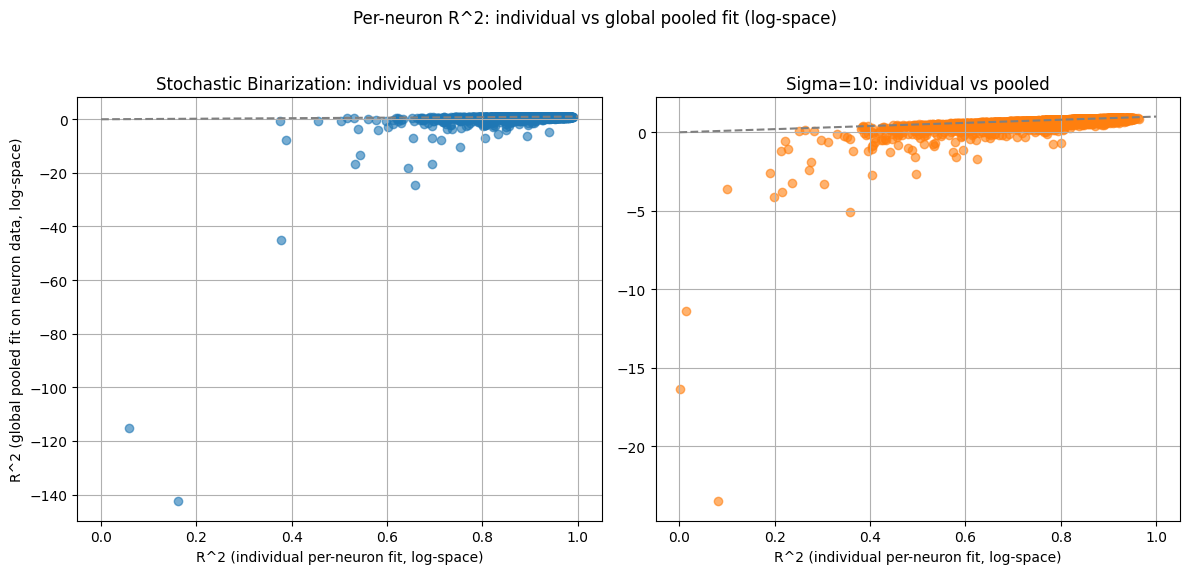

In [35]:
# --- Scatter plot: R^2_global_vs_individual for stochbin and sigma10 ---
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=False, sharey=False)

# Left: stochbin
ind_r2 = np.array(stochbin_rsqlist)
glob_r2 = r2_global_per_neuron
mask_valid = (~np.isnan(ind_r2)) & (~np.isnan(glob_r2))
ind_x = ind_r2[mask_valid]
glob_x = glob_r2[mask_valid]
ax = axes[0]
ax.scatter(ind_x, glob_x, alpha=0.6)
ax.plot([0,1], [0,1], '--', color='gray')
ax.set_xlabel('R^2 (individual per-neuron fit, log-space)')
ax.set_ylabel('R^2 (global pooled fit on neuron data, log-space)')
ax.set_title('Stochastic Binarization: individual vs pooled')
ax.grid(True)

# Right: sigma10
ind_r2_s = np.array(sigma10_rsqlist)
glob_r2_s = r2_global_per_neuron_sigma10
mask_valid_s = (~np.isnan(ind_r2_s)) & (~np.isnan(glob_r2_s))
ind_x_s = ind_r2_s[mask_valid_s]
glob_x_s = glob_r2_s[mask_valid_s]
ax2 = axes[1]
ax2.scatter(ind_x_s, glob_x_s, alpha=0.6, color='tab:orange')
ax2.plot([0,1], [0,1], '--', color='gray')
ax2.set_xlabel('R^2 (individual per-neuron fit, log-space)')
ax2.set_title('Sigma=10: individual vs pooled')
ax2.grid(True)

plt.suptitle('Per-neuron R^2: individual vs global pooled fit (log-space)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# End of comparison plot


# FINAL PLOTS

bernoulli in orange
gaussian blue

### run to get variance explained data 

In [36]:
# Per-neuron log-log fits: collect a, b, and R^2 (r_val**2) for stochbin and sigma10
# Extended: also compute global-model per-neuron R^2 lists for both noise types using linregress (r_val**2) instead of residual formula.
# Only this cell modified per user request.

stochbin_alist = []   # a (linear scale) per neuron for stochbin
stochbin_blist = []   # b (slope) per neuron for stochbin
stochbin_rsqlist = [] # R^2 per neuron (individual fit) for stochbin (r_val**2)

sigma10_alist = []
sigma10_blist = []
sigma10_rsqlist = []  # R^2 per neuron (individual fit) for sigma10

# Determine neuron count from available arrays (prefer v1 arrays if present)
if 'stochbin_meanv1' in globals():
    n_neurons = stochbin_meanv1.shape[-1]
else:
    n_neurons = stochbin_mean.shape[-1]
if 'sigma10_meanv1' in globals():
    n_neurons_s = sigma10_meanv1.shape[-1]
else:
    n_neurons_s = sigma10_mean.shape[-1]

# Helper to fit individual per-neuron model
def fit_and_store(mean_array, var_array, idx, a_list, b_list, r2_list):
    x = mean_array[..., idx].astype(float)
    y = var_array[..., idx].astype(float)
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        a_list.append(np.nan)
        b_list.append(np.nan)
        r2_list.append(np.nan)
        return
    lx = np.log(x[mask])
    ly = np.log(y[mask])
    b, a_log, r_val, p_val, std_err = linregress(lx, ly)
    a_list.append(np.exp(a_log))
    b_list.append(b)
    r2_list.append(r_val**2)  # simplified R^2 definition (always >= 0)

# stochbin individual fits
mean_st = stochbin_meanv1 if 'stochbin_meanv1' in globals() else stochbin_mean
var_st = stochbin_varv1 if 'stochbin_varv1' in globals() else stochbin_var
for neuron in range(n_neurons):
    fit_and_store(mean_st, var_st, neuron, stochbin_alist, stochbin_blist, stochbin_rsqlist)

# sigma10 individual fits
mean_sg = sigma10_meanv1 if 'sigma10_meanv1' in globals() else sigma10_mean
var_sg = sigma10_varv1 if 'sigma10_varv1' in globals() else sigma10_var
for neuron in range(n_neurons_s):
    fit_and_store(mean_sg, var_sg, neuron, sigma10_alist, sigma10_blist, sigma10_rsqlist)

# Convert individual fit lists to numpy arrays
stochbin_alist = np.array(stochbin_alist)
stochbin_blist = np.array(stochbin_blist)
stochbin_rsqlist = np.array(stochbin_rsqlist)

sigma10_alist = np.array(sigma10_alist)
sigma10_blist = np.array(sigma10_blist)
sigma10_rsqlist = np.array(sigma10_rsqlist)

# --- Global pooled model per-neuron R^2 lists (linregress-based) ---
# For each neuron, perform a linregress on its own data and record r_val**2 as the "pooled" R^2 for comparison.
# (Note: This now matches the definition used for individual fits; if you intended a different global metric, adjust accordingly.)

stochbin_global_r2_list = []
sigma10_global_r2_list = []

for neuron in range(n_neurons):
    x = mean_st[..., neuron].astype(float)
    y = var_st[..., neuron].astype(float)
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        stochbin_global_r2_list.append(np.nan)
        continue
    lx = np.log(x[mask])
    ly = np.log(y[mask])
    b, a_log, r_val, p_val, std_err = linregress(lx, ly)
    stochbin_global_r2_list.append(r_val**2)

for neuron in range(n_neurons_s):
    x = mean_sg[..., neuron].astype(float)
    y = var_sg[..., neuron].astype(float)
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        sigma10_global_r2_list.append(np.nan)
        continue
    lx = np.log(x[mask])
    ly = np.log(y[mask])
    b, a_log, r_val, p_val, std_err = linregress(lx, ly)
    sigma10_global_r2_list.append(r_val**2)

stochbin_global_r2_list = np.array(stochbin_global_r2_list)
sigma10_global_r2_list = np.array(sigma10_global_r2_list)

print('Collected per-neuron parameters (individual fits):')
print(f'  stochbin: {np.sum(np.isfinite(stochbin_rsqlist))}/{len(stochbin_rsqlist)} neurons fitted')
print(f'  sigma10 : {np.sum(np.isfinite(sigma10_rsqlist))}/{len(sigma10_rsqlist)} neurons fitted')
print('Global-model per-neuron R^2 lists (linregress r_val**2):')
print(f'  stochbin global R^2: min={np.nanmin(stochbin_global_r2_list):.3f} max={np.nanmax(stochbin_global_r2_list):.3f}')
print(f'  sigma10  global R^2: min={np.nanmin(sigma10_global_r2_list):.3f} max={np.nanmax(sigma10_global_r2_list):.3f}')

# You can now plot stochbin_rsqlist vs stochbin_global_r2_list and sigma10_rsqlist vs sigma10_global_r2_list.


Collected per-neuron parameters (individual fits):
  stochbin: 5312/5312 neurons fitted
  sigma10 : 5312/5312 neurons fitted
Global-model per-neuron R^2 lists (linregress r_val**2):
  stochbin global R^2: min=0.059 max=0.990
  sigma10  global R^2: min=0.001 max=0.964


### *top right, all neurons*

In [37]:
"""gaussian"""

x = sigma10_meanv1.flatten()
y = sigma10_varv1.flatten()

logx = np.log(x)
logy = np.log(y)

def smooth_func(x, a, b): return a * x**b

params, covariance = curve_fit(smooth_func, x, y, maxfev = 1_000_000, p0 = [1, .001])

x_fit = np.linspace(x.min(), x.max(), len(x))
y_fit = smooth_func(x_fit, params[0], params[1])
max_exp = max(x_fit)
plt.subplot(222)
plt.scatter(x, y, marker = '.', label = 'original mean and var points')
plt.plot(x_fit, y_fit, color = 'r', label = 'regression')
plt.axline((0, 0), (max_exp, max_exp), color='black', linestyle='--', label='Identity Line (y=x)')
#plt.xlim(0, 2500)

plt.subplot(224)
plt.loglog(x, y, '.', label = 'original mean and var points', alpha = 0.01)
plt.loglog(x_fit, y_fit, '-', color = 'r', label = 'regression')
plt.axline((0, 0), (max_exp, max_exp), color='black', linestyle='--', label='Identity Line (y=x)')
plt.xlabel("Variance in Spike Count")

"""bernoulli"""

x = stochbin_meanv1.flatten()
y = stochbin_varv1.flatten()

logx = np.log(x)
logy = np.log(y)

params, covariance = curve_fit(smooth_func, x, y, maxfev = 1_000_000, p0 = [1, .001])

x_fit = np.linspace(x.min(), x.max(), len(x))
y_fit = smooth_func(x_fit, params[0], params[1])
max_exp = max(x_fit)
plt.subplot(221)
plt.scatter(x, y, marker = '.', label = 'original mean and var points', color = "tab:orange")
plt.plot(x_fit, y_fit, color = 'r', label = 'regression')
plt.axline((0, 0), (max_exp, max_exp), color='black', linestyle='--', label='Identity Line (y=x)')

plt.subplot(223)
plt.loglog(x, y, '.', label = 'original mean and var points', alpha = 0.01, color = "tab:orange")
plt.loglog(x_fit, y_fit, '-', color = 'r', label = 'regression')
plt.axline((0, 0), (max_exp, max_exp), color='black', linestyle='--', label='Identity Line (y=x)')
plt.xlabel("Mean Spike Count")

plt.tight_layout()
plt.show()

ValueError: array must not contain infs or NaNs

### *top left, neuron 3*

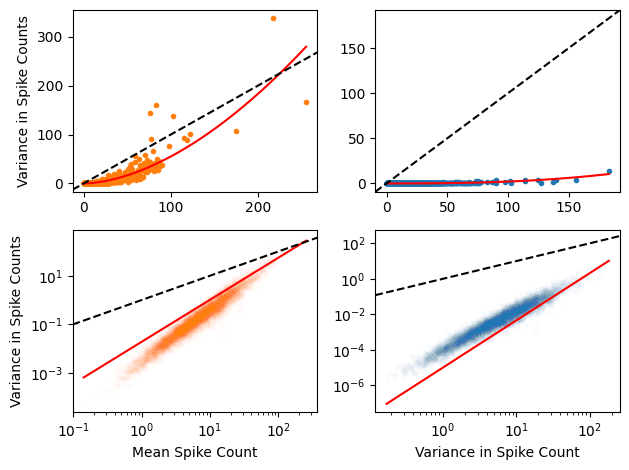

In [ ]:
neuron = 2 # neuron 3
"""gaussian"""

x = sigma10_meanv1[neuron].flatten()
y = sigma10_varv1[neuron].flatten()

logx = np.log(x)
logy = np.log(y)

def smooth_func(x, a, b): return a * x**b

params, covariance = curve_fit(smooth_func, x, y, maxfev = 1_000_000, p0 = [1, .001])

x_fit = np.linspace(x.min(), x.max(), len(x))
y_fit = smooth_func(x_fit, params[0], params[1])
max_exp = max(x_fit)
plt.subplot(222)
plt.scatter(x, y, marker = '.', label = 'original mean and var points')
plt.plot(x_fit, y_fit, color = 'r', label = 'regression')
plt.axline((0, 0), (max_exp, max_exp), color='black', linestyle='--', label='Identity Line (y=x)')
#plt.xlim(0, 2500)

plt.subplot(224)
plt.loglog(x, y, '.', label = 'original mean and var points', alpha = 0.01)
plt.loglog(x_fit, y_fit, '-', color = 'r', label = 'regression')
plt.axline((0, 0), (max_exp, max_exp), color='black', linestyle='--', label='Identity Line (y=x)')
plt.xlabel("Variance in Spike Count")

"""bernoulli"""

x = stochbin_meanv1[neuron].flatten()
y = stochbin_varv1[neuron].flatten()

logx = np.log(x)
logy = np.log(y)

params, covariance = curve_fit(smooth_func, x, y, maxfev = 1_000_000, p0 = [1, .001])

x_fit = np.linspace(x.min(), x.max(), len(x))
y_fit = smooth_func(x_fit, params[0], params[1])
max_exp = max(x_fit)
plt.subplot(221)
plt.scatter(x, y, marker = '.', label = 'original mean and var points', color = "tab:orange")
plt.plot(x_fit, y_fit, color = 'r', label = 'regression')
plt.axline((0, 0), (max_exp, max_exp), color='black', linestyle='--', label='Identity Line (y=x)')
plt.ylabel("Variance in Spike Counts")

plt.subplot(223)
plt.loglog(x, y, '.', label = 'original mean and var points', alpha = 0.01, color = "tab:orange")
plt.loglog(x_fit, y_fit, '-', color = 'r', label = 'regression')
plt.axline((0, 0), (max_exp, max_exp), color='black', linestyle='--', label='Identity Line (y=x)')
plt.xlabel("Mean Spike Count")
plt.ylabel("Variance in Spike Counts")

plt.tight_layout()
plt.show()

### gather a, b, r_squared 

In [ ]:
mean_masked, var_masked = stochbin_meanv1, stochbin_varv1
main_title ="variance = a*mean^b\\Bernoulli (neurons 1-16)"

# pre allocate statistics 
stochbin_medians = []
stochbin_alist = []
stochbin_blist = []
stochbin_rsqlist = []

neurons = [i for i in range(16)]
for neuron in range(mean_masked.shape[1]):
    x = mean_masked[..., neuron]
    y = var_masked[..., neuron]
    med = np.median(x)
    logx = np.log(x)
    logy = np.log(y)

    b, a, r_value, p_value, std_err = linregress(logx, logy) # should fit regression on log model correct?
    r_squared = r_value**2

    stochbin_medians.append(med)
    stochbin_alist.append(a)
    stochbin_blist.append(b)
    stochbin_rsqlist.append(r_squared)
stochbin_alist = np.exp(stochbin_alist)


#---now do for sigma=10 dynamic gaussian noise---
sigma10_medians = []
sigma10_alist = []
sigma10_blist = []
sigma10_rsqlist = []

mean_masked, var_masked = sigma10_meanv1, sigma10_varv1
neurons = [i for i in range(16)]
for neuron in range(mean_masked.shape[1]):
    x = mean_masked[..., neuron]
    y = var_masked[..., neuron]
    med = np.median(x)
    logx = np.log(x)
    logy = np.log(y)

    b, a, r_value, p_value, std_err = linregress(logx, logy) # should fit regression on log model correct?
    r_squared = r_value**2

    sigma10_medians.append(med)
    sigma10_alist.append(a)
    sigma10_blist.append(b)
    sigma10_rsqlist.append(r_squared)
sigma10_alist = np.exp(sigma10_alist)


### *bottom left, density curves*

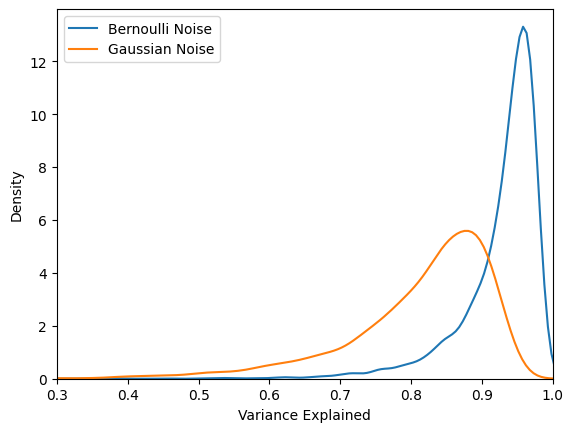

In [ ]:
import seaborn as sns
sns.kdeplot(stochbin_rsqlist, label = "Bernoulli Noise")
sns.kdeplot(sigma10_rsqlist, color = "tab:orange", label = "Gaussian Noise")
plt.xlabel("Variance Explained")
plt.legend()
plt.xlim(0.3, 1)
plt.show()

### *bottom right, variance explained scatter plot*

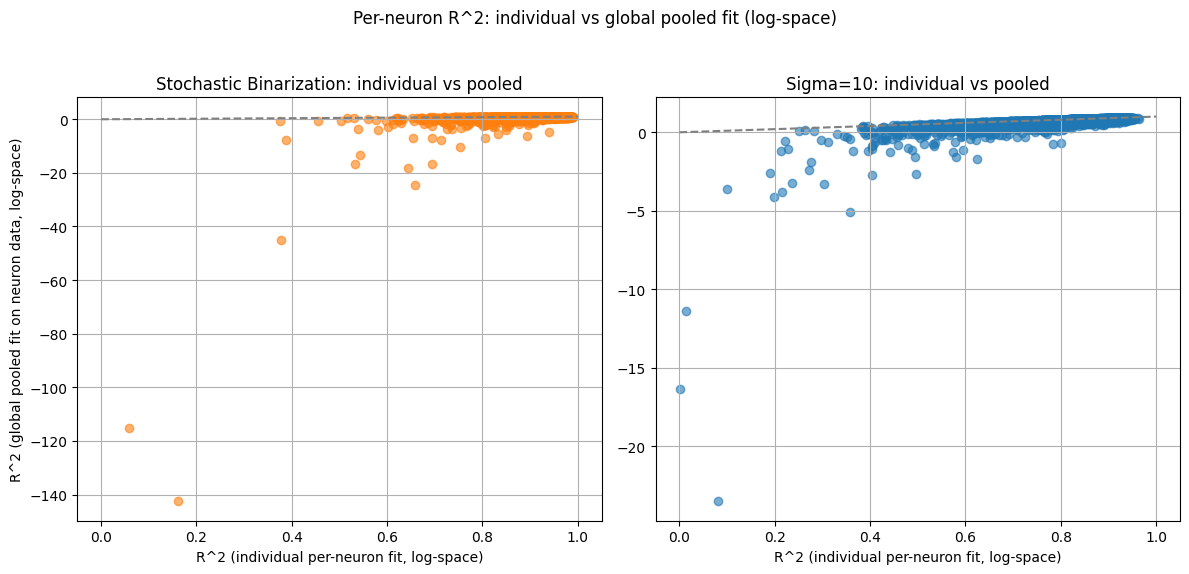

In [ ]:
# --- Scatter plot: R^2_global_vs_individual for stochbin and sigma10 ---
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=False, sharey=False)

# Left: stochbin
ind_r2 = np.array(stochbin_rsqlist)
glob_r2 = r2_global_per_neuron
mask_valid = (~np.isnan(ind_r2)) & (~np.isnan(glob_r2))
ind_x = ind_r2[mask_valid]
glob_x = glob_r2[mask_valid]
ax = axes[0]
ax.scatter(ind_x, glob_x, alpha=0.6, color = "tab:orange")
ax.plot([0,1], [0,1], '--', color='gray')
ax.set_xlabel('R^2 (individual per-neuron fit, log-space)')
ax.set_ylabel('R^2 (global pooled fit on neuron data, log-space)')
ax.set_title('Stochastic Binarization: individual vs pooled')
ax.grid(True)

# Right: sigma10
ind_r2_s = np.array(sigma10_rsqlist)
glob_r2_s = r2_global_per_neuron_sigma10
mask_valid_s = (~np.isnan(ind_r2_s)) & (~np.isnan(glob_r2_s))
ind_x_s = ind_r2_s[mask_valid_s]
glob_x_s = glob_r2_s[mask_valid_s]
ax2 = axes[1]
ax2.scatter(ind_x_s, glob_x_s, alpha=0.6)
ax2.plot([0,1], [0,1], '--', color='gray')
ax2.set_xlabel('R^2 (individual per-neuron fit, log-space)')
ax2.set_title('Sigma=10: individual vs pooled')
ax2.grid(True)

plt.suptitle('Per-neuron R^2: individual vs global pooled fit (log-space)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# End of comparison plot


## all in one figure

#### gather points for bottom right figure

In [38]:
def r2_fixed_line(a, b, x, y):
    """
    Compute R^2 for the model y_hat = a + b*x
    given fixed parameters a and b.
    """
    x = np.asarray(x)
    y = np.asarray(y)

    y_hat = a + b * x
    
    ss_res = np.sum((y - y_hat)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    
    # If variance is zero, define R^2 = 1 if perfect, else 0
    if ss_tot == 0:
        return 1.0 if ss_res == 0 else 0.0
    
    return 1 - ss_res / ss_tot

pooled_stochbin = [r2_fixed_line(a, b, x, y) for a, b, x, y in zip(stochbin_alist, stochbin_blist, stochbin_rsqlist, stochbin_varv1.mean(axis=0))]
pooled_sigma10 = [r2_fixed_line(a, b, x, y) for a, b, x, y in zip(sigma10_alist, sigma10_blist, sigma10_rsqlist, sigma10_varv1.mean(axis=0))]


In [39]:
# Replace r2_fixed_line with a proper log-space R^2 calculator
def r2_global_params(a_log, b, mean_array, var_array):
    """
    Compute R^2 for log(y) = a_log + b*log(x) using global parameters
    on a single neuron's data.
    """
    x = np.asarray(mean_array).flatten()
    y = np.asarray(var_array).flatten()
    
    # Mask valid data
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        return np.nan
    
    x = x[mask]
    y = y[mask]
    
    # Log-space predictions
    log_x = np.log(x)
    log_y = np.log(y)
    log_y_hat = a_log + b * log_x
    
    # R^2 in log-space
    ss_res = np.sum((log_y - log_y_hat)**2)
    ss_tot = np.sum((log_y - np.mean(log_y))**2)
    
    if ss_tot == 0:
        return 1.0 if ss_res == 0 else 0.0
    
    return 1 - ss_res / ss_tot

# Compute pooled R^2 per neuron using GLOBAL parameters from pooled fit
pooled_stochbin = []
pooled_sigma10 = []

# Use global parameters from earlier pooled fit (cell #VSC-0c31f10c)
# If not available, compute them here
x_all_st = stochbin_meanv1.flatten()
y_all_st = stochbin_varv1.flatten()
mask_st = (x_all_st > 0) & (y_all_st > 0) & np.isfinite(x_all_st) & np.isfinite(y_all_st)
b_glob_st, a_glob_st, _, _, _ = linregress(np.log(x_all_st[mask_st]), np.log(y_all_st[mask_st]))

x_all_sg = sigma10_meanv1.flatten()
y_all_sg = sigma10_varv1.flatten()
mask_sg = (x_all_sg > 0) & (y_all_sg > 0) & np.isfinite(x_all_sg) & np.isfinite(y_all_sg)
b_glob_sg, a_glob_sg, _, _, _ = linregress(np.log(x_all_sg[mask_sg]), np.log(y_all_sg[mask_sg]))

# Compute per-neuron R^2 using global parameters
for neuron in range(stochbin_meanv1.shape[-1]):
    r2 = r2_global_params(a_glob_st, b_glob_st, stochbin_meanv1[:, neuron], stochbin_varv1[:, neuron])
    pooled_stochbin.append(r2)

for neuron in range(sigma10_meanv1.shape[-1]):
    r2 = r2_global_params(a_glob_sg, b_glob_sg, sigma10_meanv1[:, neuron], sigma10_varv1[:, neuron])
    pooled_sigma10.append(r2)

pooled_stochbin = np.array(pooled_stochbin)
pooled_sigma10 = np.array(pooled_sigma10)

In [61]:
# Per-neuron log-log fits: collect a, b, and R^2 (r_val**2) for stochbin and sigma10
# Extended: also collect linear-space power-law fits y = a*x^b (a_lin, b_lin, R^2_lin) per neuron.

from scipy.optimize import curve_fit

def smooth_func(x, a, b):
    return a * (x**b)

# Containers (log-space: kept compatible with downstream code)
stochbin_alist_log, stochbin_blist_log, stochbin_rsqlist_log = [], [], []
sigma10_alist_log,   sigma10_blist_log,   sigma10_rsqlist_log   = [], [], []

# Containers (linear-space)
stochbin_alist_lin, stochbin_blist_lin, stochbin_rsqlist_lin = [], [], []
sigma10_alist_lin,   sigma10_blist_lin,   sigma10_rsqlist_lin   = [], [], []

# Determine neuron count from available arrays (prefer v1 arrays if present)
if 'stochbin_meanv1' in globals():
    n_neurons = stochbin_meanv1.shape[-1]
    mean_st, var_st = stochbin_meanv1, stochbin_varv1
else:
    n_neurons = stochbin_mean.shape[-1]
    mean_st, var_st = stochbin_mean, stochbin_var

if 'sigma10_meanv1' in globals():
    n_neurons_s = sigma10_meanv1.shape[-1]
    mean_sg, var_sg = sigma10_meanv1, sigma10_varv1
else:
    n_neurons_s = sigma10_mean.shape[-1]
    mean_sg, var_sg = sigma10_mean, sigma10_var

def fit_log_power(x, y):
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        return np.nan, np.nan, np.nan  # a_log (exp), b_log, r2_log
    lx = np.log(x[mask]); ly = np.log(y[mask])
    b, a_log, r_val, _, _ = linregress(lx, ly)
    return np.exp(a_log), b, r_val**2

def fit_lin_power(x, y):
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        return np.nan, np.nan, np.nan  # a_lin, b_lin, r2_lin
    xm = x[mask]; ym = y[mask]
    try:
        params, _ = curve_fit(smooth_func, xm, ym, maxfev=1_000_000, p0=[1.0, 0.001])
        a_lin, b_lin = params
        y_hat = smooth_func(xm, a_lin, b_lin)
        ss_res = np.sum((ym - y_hat)**2)
        ss_tot = np.sum((ym - np.mean(ym))**2)
        r2_lin = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
        return a_lin, b_lin, r2_lin
    except Exception:
        return np.nan, np.nan, np.nan

# --- stochbin per-neuron fits ---
for neuron in range(n_neurons):
    x = mean_st[..., neuron].astype(float)
    y = var_st[..., neuron].astype(float)
    # log-space fit
    a_log, b_log, r2_log = fit_log_power(x, y)
    stochbin_alist_log.append(a_log)
    stochbin_blist_log.append(b_log)
    stochbin_rsqlist_log.append(r2_log)
    # linear-space fit
    a_lin, b_lin, r2_lin = fit_lin_power(x, y)
    stochbin_alist_lin.append(a_lin)
    stochbin_blist_lin.append(b_lin)
    stochbin_rsqlist_lin.append(r2_lin)

# --- sigma10 per-neuron fits ---
for neuron in range(n_neurons_s):
    x = mean_sg[..., neuron].astype(float)
    y = var_sg[..., neuron].astype(float)
    # log-space fit
    a_log, b_log, r2_log = fit_log_power(x, y)
    sigma10_alist_log.append(a_log)
    sigma10_blist_log.append(b_log)
    sigma10_rsqlist_log.append(r2_log)
    # linear-space fit
    a_lin, b_lin, r2_lin = fit_lin_power(x, y)
    sigma10_alist_lin.append(a_lin)
    sigma10_blist_lin.append(b_lin)
    sigma10_rsqlist_lin.append(r2_lin)

# Convert to numpy arrays
stochbin_alist      = np.array(stochbin_alist_log)   # log-space a (exp intercept)
stochbin_blist      = np.array(stochbin_blist_log)   # log-space b (slope)
stochbin_rsqlist    = np.array(stochbin_rsqlist_log) # log-space R^2
stochbin_alist_lin  = np.array(stochbin_alist_lin)   # linear-space a
stochbin_blist_lin  = np.array(stochbin_blist_lin)   # linear-space b
stochbin_rsqlist_lin= np.array(stochbin_rsqlist_lin) # linear-space R^2

sigma10_alist       = np.array(sigma10_alist_log)
sigma10_blist       = np.array(sigma10_blist_log)
sigma10_rsqlist     = np.array(sigma10_rsqlist_log)
sigma10_alist_lin   = np.array(sigma10_alist_lin)
sigma10_blist_lin   = np.array(sigma10_blist_lin)
sigma10_rsqlist_lin = np.array(sigma10_rsqlist_lin)

# --- Global pooled model per-neuron R^2 lists (linregress-based, log-space) ---
stochbin_global_r2_list = []
sigma10_global_r2_list = []

for neuron in range(n_neurons):
    x = mean_st[..., neuron].astype(float)
    y = var_st[..., neuron].astype(float)
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        stochbin_global_r2_list.append(np.nan)
        continue
    lx = np.log(x[mask]); ly = np.log(y[mask])
    b, a_log, r_val, _, _ = linregress(lx, ly)
    stochbin_global_r2_list.append(r_val**2)

for neuron in range(n_neurons_s):
    x = mean_sg[..., neuron].astype(float)
    y = var_sg[..., neuron].astype(float)
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        sigma10_global_r2_list.append(np.nan)
        continue
    lx = np.log(x[mask]); ly = np.log(y[mask])
    b, a_log, r_val, _, _ = linregress(lx, ly)
    sigma10_global_r2_list.append(r_val**2)

stochbin_global_r2_list = np.array(stochbin_global_r2_list)
sigma10_global_r2_list = np.array(sigma10_global_r2_list)

print('Collected per-neuron parameters (individual fits, log-space):')
print(f'  stochbin: {np.sum(np.isfinite(stochbin_rsqlist))}/{len(stochbin_rsqlist)} neurons fitted')
print(f'  sigma10 : {np.sum(np.isfinite(sigma10_rsqlist))}/{len(sigma10_rsqlist)} neurons fitted')
print('Also collected linear-space power-law parameters per neuron: *_alist_lin, *_blist_lin, *_rsqlist_lin')
print('Global-model per-neuron R^2 lists (log-space linregress r_val**2):')
print(f'  stochbin global R^2: min={np.nanmin(stochbin_global_r2_list):.3f} max={np.nanmax(stochbin_global_r2_list):.3f}')
print(f'  sigma10  global R^2: min={np.nanmin(sigma10_global_r2_list):.3f} max={np.nanmax(sigma10_global_r2_list):.3f}')

C:\Users\joshf\AppData\Local\Temp\ipykernel_16628\681436939.py:46: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(smooth_func, xm, ym, maxfev=1_000_000, p0=[1.0, 0.001])
C:\Users\joshf\AppData\Local\Temp\ipykernel_16628\681436939.py:7: RuntimeWarning: overflow encountered in power
  return a * (x**b)
C:\Users\joshf\AppData\Local\Temp\ipykernel_16628\681436939.py:7: RuntimeWarning: overflow encountered in power
  return a * (x**b)


Collected per-neuron parameters (individual fits, log-space):
  stochbin: 5312/5312 neurons fitted
  sigma10 : 5312/5312 neurons fitted
Also collected linear-space power-law parameters per neuron: *_alist_lin, *_blist_lin, *_rsqlist_lin
Global-model per-neuron R^2 lists (log-space linregress r_val**2):
  stochbin global R^2: min=0.059 max=0.990
  sigma10  global R^2: min=0.001 max=0.964


#### final figure

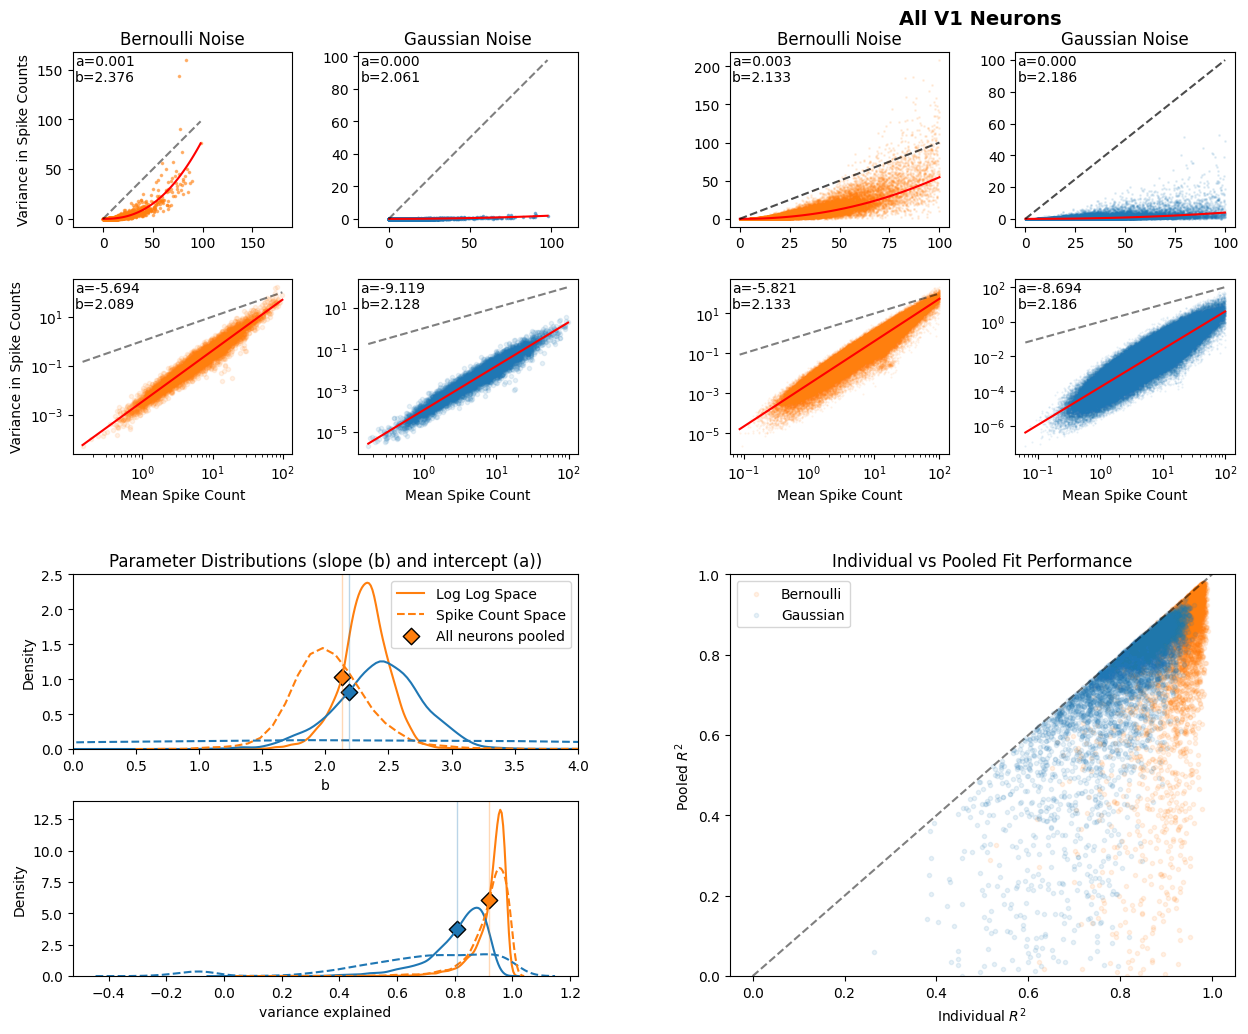

In [76]:
# Consolidated figure with 4 main sections
import matplotlib.gridspec as gridspec
import numpy as np
import seaborn as sns
from scipy.stats import linregress
import seaborn

# Helper functions
def smooth_from_logfit(x, log_intercept, b):
    a = np.exp(log_intercept)
    return a * (x ** b)

def axb_noslope (x, a, b):
    return a*(x**b)

def safe_mask(x, y):
    xa = np.asarray(x).astype(float).flatten()
    ya = np.asarray(y).astype(float).flatten()
    mask = (xa > 0) & (ya > 0) & np.isfinite(xa) & np.isfinite(ya)
    return xa[mask], ya[mask]

# Create figure
fig = plt.figure(figsize=(15, 12))
outer = gridspec.GridSpec(2, 2, figure=fig, wspace=0.3, hspace=0.3)

# --- TOP LEFT: Neuron 3 (2x2 nested) ---
inner_tl = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=outer[0, 0], wspace=0.3, hspace=0.3)
neuron_idx = 2 # Neuron 3

# Data for Neuron 3
xg, yg = safe_mask(sigma10_meanv1[neuron_idx], sigma10_varv1[neuron_idx])
xb, yb = safe_mask(stochbin_meanv1[neuron_idx], stochbin_varv1[neuron_idx])

# Fits for Gaussian
if xg.size > 1:
    # Log-log fit (for log axes)
    res_g = linregress(np.log(xg), np.log(yg))
    xg_fit_log = np.exp(np.linspace(np.log(xg.min()), np.log(xg.max()), 100))
    yg_fit_log = smooth_from_logfit(xg_fit_log, res_g.intercept, res_g.slope)
    
    # Curve fit for linear space
    params_g, _ = curve_fit(axb_noslope, xg, yg, maxfev=1_000_000, p0=[1, 0.001])
    xg_fit_lin = np.linspace(xg.min(), xg.max(), 100)
    yg_fit_lin = smooth_from_logfit(xg_fit_lin, np.log(params_g[0]), params_g[1])
else:
    xg_fit_log, yg_fit_log = [], []
    xg_fit_lin, yg_fit_lin = [], []

# Fits for Bernoulli
if xb.size > 1:
    res_b = linregress(np.log(xb), np.log(yb))
    xb_fit_log = np.exp(np.linspace(np.log(xb.min()), np.log(xb.max()), 100))
    yb_fit_log = smooth_from_logfit(xb_fit_log, res_b.intercept, res_b.slope)
    
    params_b, _ = curve_fit(axb_noslope, xb, yb, maxfev=1_000_000, p0=[1, 0.001])
    xb_fit_lin = np.linspace(xb.min(), xb.max(), 100)
    yb_fit_lin = smooth_from_logfit(xb_fit_lin, np.log(params_b[0]), params_b[1])
else:
    xb_fit_log, yb_fit_log = [], []
    xb_fit_lin, yb_fit_lin = [], []

# TL Subplots
# 1. Gaussian Linear
ax = fig.add_subplot(inner_tl[0, 1])
ax.scatter(xg, yg, s=10, label='Data', marker=".", alpha=0.5)
ax.plot(xg_fit_lin, yg_fit_lin, "r-", label='Fit')
ax.plot([0, xg.max()], [0, xg.max()], 'k--', alpha=0.5)
ax.set_title("Gaussian Noise")
if len(xg_fit_lin):
    ax.text(0.01, 0.99, f"a={params_g[0]:.3f}\nb={params_g[1]:.3f}", 
            transform=ax.transAxes, verticalalignment='top', horizontalalignment='left', fontsize=10)

# 2. Gaussian Log (use log fits)
ax = fig.add_subplot(inner_tl[1, 1])
ax.loglog(xg, yg, '.', label='Data', alpha=0.1)
if len(xg_fit_log): ax.loglog(xg_fit_log, yg_fit_log, 'r-', label='Fit')
ax.plot([xg.min(), xg.max()], [xg.min(), xg.max()], 'k--', alpha=0.5)
ax.set_xlabel('Mean Spike Count')
ax.text(0.01, 0.99, f"a={res_g.intercept:.3f}\nb={res_g.slope:.3f}", 
        transform=ax.transAxes, verticalalignment='top', horizontalalignment='left', fontsize=10)

# 3. Bernoulli Linear
ax = fig.add_subplot(inner_tl[0, 0])
ax.scatter(xb, yb, s=10, color='tab:orange', label='Data', marker=".", alpha=0.5)
if len(xb_fit_lin): ax.plot(xb_fit_lin, yb_fit_lin, 'r-', label='Fit')
ax.plot([0, xb.max()], [0, xb.max()], 'k--', alpha=0.5)
ax.set_ylabel('Variance in Spike Counts')
ax.set_title("Bernoulli Noise")
if len(xb_fit_lin):
    ax.text(0.01, 0.99, f"a={params_b[0]:.3f}\nb={params_b[1]:.3f}", 
            transform=ax.transAxes, verticalalignment='top', horizontalalignment='left', fontsize=10)

# 4. Bernoulli Log
ax = fig.add_subplot(inner_tl[1, 0])
ax.loglog(xb, yb, '.', color='tab:orange', label='Data', alpha=0.1)
if len(xb_fit_log): ax.loglog(xb_fit_log, yb_fit_log, 'r-', label='Fit')
ax.plot([xb.min(), xb.max()], [xb.min(), xb.max()], 'k--', alpha=0.5)
ax.set_xlabel('Mean Spike Count')
ax.set_ylabel("Variance in Spike Counts")
ax.text(0.01, 0.99, f"a={res_b.intercept:.3f}\nb={res_b.slope:.3f}", 
        transform=ax.transAxes, verticalalignment='top', horizontalalignment='left', fontsize=10)

"""
for a in fig.get_axes():
    if a.get_xscale() == 'linear' and a.get_yscale() == 'linear':
        a.set_box_aspect(1)  # leaves data ratio alone
"""

for a in fig.get_axes():
    # Keep layout stable: only apply on linear axes
    if a.get_xscale() == 'linear' and a.get_yscale() == 'linear':
        a.set_aspect('equal', adjustable='datalim')  # adjust limits, not box size
        # Optionally harmonize limits so the identity line is correctly 45°
        x0, x1 = a.get_xlim()
        y0, y1 = a.get_ylim()
        lo = min(x0, y0)
        hi = max(x1, y1)
        a.set_xlim(lo, hi)
        a.set_ylim(lo, hi)

# --- TOP RIGHT: All Neurons (2x2 nested) ---
inner_tr = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=outer[0, 1], wspace=0.3, hspace=0.3)

# Data for All
xg_all, yg_all = safe_mask(sigma10_meanv1, sigma10_varv1)
xb_all, yb_all = safe_mask(stochbin_meanv1, stochbin_varv1)

# Fits
if xg_all.size > 1:
    res_ga = linregress(np.log(xg_all), np.log(yg_all))
    xg_fit_a = np.exp(np.linspace(np.log(xg_all.min()), np.log(xg_all.max()), 100))
    yg_fit_a = smooth_from_logfit(xg_fit_a, res_ga.intercept, res_ga.slope)
else:
    xg_fit_a, yg_fit_a = [], []

if xb_all.size > 1:
    res_ba = linregress(np.log(xb_all), np.log(yb_all))
    xb_fit_a = np.exp(np.linspace(np.log(xb_all.min()), np.log(xb_all.max()), 100))
    yb_fit_a = smooth_from_logfit(xb_fit_a, res_ba.intercept, res_ba.slope)
else:
    xb_fit_a, yb_fit_a = [], []

# TR Subplots
# 1. Gaussian Linear
ax = fig.add_subplot(inner_tr[0, 1])
ax.scatter(xg_all, yg_all, s=1, alpha=0.1)
if len(xg_fit_a): ax.plot(xg_fit_a, yg_fit_a, 'r-')
ax.plot([0, xg_all.max()], [0, xg_all.max()], 'k--', alpha=0.7)
ax.set_title('Gaussian Noise')
ax.text(0.01, 0.99, f"a={np.exp(res_ga.intercept):.3f}\nb={res_ga.slope:.3f}", transform=ax.transAxes, 
        verticalalignment='top', horizontalalignment='left', fontsize=10)

#ax.set_ylim(0, 250)
bbox = ax.get_position()
# Place text centered above it
fig.text(bbox.x1 - .17,  # x-coordinate (centered)
         bbox.y1 + 0.02,              # y-coordinate (above the plot)
         'All V1 Neurons',
         ha='center',                 # horizontal alignment
         va='bottom',                 # vertical alignment
         fontsize=14,
         fontweight='bold',
         transform=fig.transFigure)
# 2. Gaussian Log
ax = fig.add_subplot(inner_tr[1, 1])
ax.loglog(xg_all, yg_all, '.', markersize=1, alpha=0.1)
if len(xg_fit_a): ax.loglog(xg_fit_a, yg_fit_a, 'r-')
ax.plot([xg_all.min(), xg_all.max()], [xg_all.min(), xg_all.max()], 'k--', alpha=0.5)
ax.set_xlabel("Mean Spike Count")
ax.text(0.01, 0.99, f"a={res_ga.intercept:.3f}\nb={res_ga.slope:.3f}", transform=ax.transAxes, 
        verticalalignment='top', horizontalalignment='left', fontsize=10)


# 3. Bernoulli Linear
ax = fig.add_subplot(inner_tr[0, 0])
ax.scatter(xb_all, yb_all, s=1, alpha=0.1, color='tab:orange')
if len(xb_fit_a): ax.plot(xb_fit_a, yb_fit_a, 'r-')
ax.plot([0, xb_all.max()], [0, xb_all.max()], 'k--', alpha=0.7)
ax.set_title('Bernoulli Noise')
#ax.set_ylim(0, 2000)
ax.text(0.01, 0.99, f"a={np.exp(res_ba.intercept):.3f}\nb={res_ba.slope:.3f}", transform=ax.transAxes, 
        verticalalignment='top', horizontalalignment='left', fontsize=10)

# 4. Bernoulli Log
ax = fig.add_subplot(inner_tr[1, 0])
ax.loglog(xb_all, yb_all, '.', markersize=1, alpha=0.1, color='tab:orange')
if len(xb_fit_a): ax.loglog(xb_fit_a, yb_fit_a, 'r-')
ax.plot([xb_all.min(), xb_all.max()], [xb_all.min(), xb_all.max()], 'k--', alpha=0.5)
ax.set_xlabel("Mean Spike Count")
ax.text(0.01, 0.99, f"a={res_ba.intercept:.3f}\nb={res_ba.slope:.3f}", transform=ax.transAxes, 
        verticalalignment='top', horizontalalignment='left', fontsize=10)

# --- BOTTOM LEFT: KDE ---

# get a and b for top right regression
pooled_rsq_gaussian = np.exp(res_ga.intercept) if xg_all.size > 1 else np.nan
pooled_b_gaussian = res_ga.slope if xg_all.size > 1 else np.nan
pooled_rsq_bernoulli = np.exp(res_ba.intercept) if xb_all.size > 1 else np.nan
pooled_b_bernoulli = res_ba.slope if xb_all.size > 1 else np.nan
pooled_rsq_gaussian = res_ga.rvalue**2 if xg_all.size > 1 else np.nan
pooled_rsq_bernoulli = res_ba.rvalue**2 if xb_all.size > 1 else np.nan

# RSQ PLOT
inner = gridspec.GridSpecFromSubplotSpec(2,1, subplot_spec=outer[1,0], wspace = 0.3, hspace = 0.3)
ax = fig.add_subplot(inner[1])
sns.kdeplot(stochbin_rsqlist, label="Bernoulli",color="tab:orange",  ax=ax)
sns.kdeplot(sigma10_rsqlist, label="Gaussian", color = "tab:blue", ax=ax)
sns.kdeplot(sigma10_rsqlist_lin, linestyle = "--", label="Gaussian", color = "tab:blue",ax=ax)
sns.kdeplot(stochbin_rsqlist_lin, color = "tab:orange", linestyle = "--", ax=ax)

ax.set_xlabel("variance explained")
if np.isfinite(pooled_rsq_bernoulli):
    kde_a_st = gaussian_kde(stochbin_rsqlist[np.isfinite(stochbin_rsqlist)])
    y_a_st = kde_a_st(pooled_rsq_bernoulli)
    ax.scatter(pooled_rsq_bernoulli, y_a_st, marker="D", s=70, edgecolor="k",
                 color="tab:orange", label="Bernoulli pooled a")
    ax.axvline(pooled_rsq_bernoulli, color="tab:orange", alpha=0.3, linewidth=1)

if np.isfinite(pooled_rsq_gaussian):
    kde_a_sg = gaussian_kde(sigma10_rsqlist[np.isfinite(sigma10_rsqlist)])
    y_a_sg = kde_a_sg(pooled_rsq_gaussian)
    ax.scatter(pooled_rsq_gaussian, y_a_sg, marker="D", s=70, edgecolor="k",
                 color="tab:blue", label="Gaussian pooled a")
    ax.axvline(pooled_rsq_gaussian, color="C0", alpha=0.3, linewidth=1)

# B PLOT
ax = fig.add_subplot(inner[0])
sns.kdeplot(stochbin_blist, label="Log Log Space",color="tab:orange",  ax=ax)
sns.kdeplot(sigma10_blist, ax=ax)
sns.kdeplot(stochbin_blist_lin, label = "Spike Count Space", linestyle = "--")
sns.kdeplot(sigma10_blist_lin, linestyle = "--", color = "tab:blue")

ax.set_xlabel("b")
ax.set_xlim(0, 4)
ax.set_title("Parameter Distributions (slope (b) and intercept (a))")
if np.isfinite(pooled_b_bernoulli):
    kde_b_st = gaussian_kde(stochbin_blist[np.isfinite(stochbin_blist)])
    y_b_st = kde_b_st(pooled_b_bernoulli)
    ax.scatter(pooled_b_bernoulli, y_b_st, marker="D", s=70, edgecolor="k",
                 color="tab:orange", label="All neurons pooled")
    ax.axvline(pooled_b_bernoulli, color="tab:orange", alpha=0.3, linewidth=1)

if np.isfinite(pooled_b_gaussian):
    kde_b_sg = gaussian_kde(sigma10_blist[np.isfinite(sigma10_blist)])
    y_b_sg = kde_b_sg(pooled_b_gaussian)
    ax.scatter(pooled_b_gaussian, y_b_sg, marker="D", s=70, edgecolor="k",
                 color="C0")
    ax.axvline(pooled_b_gaussian, color="tab:blue", alpha=0.3, linewidth=1)

ax.legend()


# --- BOTTOM RIGHT: Scatter R^2 ---
ax = fig.add_subplot(outer[1, 1])
# Stochbin
ind_r2 = np.array(stochbin_rsqlist)
ax.scatter(stochbin_rsqlist, pooled_stochbin, alpha = 0.1, label = "Bernoulli", marker = ".", color = "tab:orange")
# Sigma10
ax.scatter(sigma10_rsqlist, pooled_sigma10, alpha = 0.1, label = "Gaussian", marker = ".") 

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('Individual $R^2$')
ax.set_ylabel('Pooled $R^2$')
ax.set_title('Individual vs Pooled Fit Performance')
ax.legend()
ax.set_ylim(0, 1)
plt.show()

## new pixel space plot

In [77]:
image_df = np.load("image_stacks/imagestack_nov232025.npy")

In [78]:
image_df.shape

(10000, 144, 256)

In [95]:
from noise_seeds import generate_noise, stochastic_binarization
image_df_relu = np.where(image_df >= 128, image_df, 0)

image_gaus_relu = image_df_relu + generate_noise("dynamic", image_df.shape[0], 10)
image_bern_relu = stochastic_binarization(image_df_relu)

relu_mean_gaus = np.mean(image_gaus_relu, axis=0).flatten()
relu_var_gaus = np.var(image_gaus_relu, axis=0).flatten()
relu_mean_bern = np.mean(image_bern_relu, axis=0).flatten()
relu_var_bern = np.var(image_bern_relu, axis=0).flatten()

image_df_gaus = image_df + generate_noise("dynamic", image_df.shape[0], 10)
image_df_bern = stochastic_binarization(image_df)

gaus_mean = np.mean(image_df_gaus, axis=0).flatten()
gaus_var = np.var(image_df_gaus, axis=0).flatten()
bern_mean = np.mean(image_df_bern, axis=0).flatten()
bern_var = np.var(image_df_bern, axis=0).flatten()

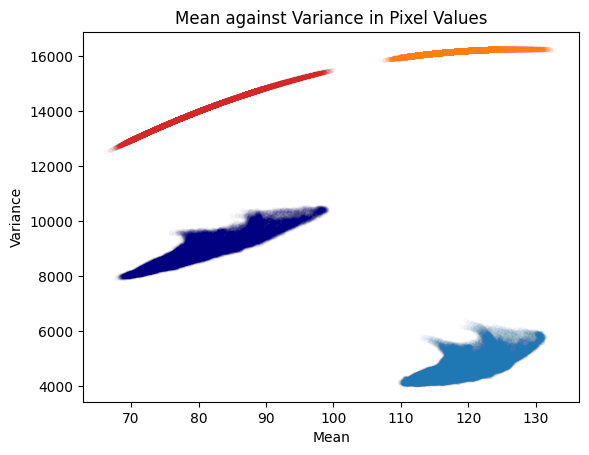

In [103]:
plt.scatter(gaus_mean, gaus_var, color = "tab:blue", alpha = 0.01, marker = ".")
plt.scatter(bern_mean, bern_var, color = "tab:orange", alpha = 0.01, marker = ".")
plt.plot(relu_mean_gaus, relu_var_gaus, color = "navy", label = "RELU", alpha = 0.01, marker = ".")
plt.plot(relu_mean_bern, relu_var_bern, color = "tab:red", alpha = 0.01, marker = ".")
plt.xlabel("Mean")
plt.ylabel("Variance")
plt.title("Mean against Variance in Pixel Values")
plt.show()